In [1]:
#Basics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV
#NB
from sklearn.naive_bayes import CategoricalNB

#Addressing class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#XGB
import xgboost as xgb
from xgboost import plot_importance

#Catboost
from catboost import CatBoostClassifier


#Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, \
    roc_auc_score, RocCurveDisplay, f1_score

#Interpretability
import shap #Explainer

#Optimization
import optuna
from optuna.samplers import TPESampler

# File systems
import os
import string

In [2]:
# Setting matplotlib style
plt.style.use('ggplot')

## Function Definitions

These functions, respectively:

*   `scatter_matrix_ex`: Generates a scatter matrix plot for numerical columns in a DataFrame.
*   `corr_matrix_ex`: Generates a heatmap of the correlation matrix for numerical columns in a DataFrame.
*   `givendf_investigation`: Investigates a given DataFrame by plotting count plots for categorical columns and histograms for numerical columns.
*   `confusion_matrix_ex`: Displays a confusion matrix for classification model evaluation.
*   `roc_curve_display_ex`: Displays a Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC) for classification model evaluation.
*   `perf_output`: Displays performance output (including above `roc_curve_display_ex`) using scikit-learn classifaction report. Can be used for both validation and test set performance.

In [3]:
def scatter_matrix_ex(numeric_df, custom_alpha=0.05):
  axs = pd.plotting.scatter_matrix(numeric_df, figsize=(30,16), alpha=custom_alpha, diagonal='kde')

  numeric_n = len(numeric_df.columns)
  for x in range(numeric_n):
      for y in range(numeric_n):
          ax = axs[x, y]
          ax.xaxis.label.set_rotation(90)
          ax.yaxis.label.set_rotation(0)
          ax.yaxis.labelpad = 50
          ax.xaxis.label.set_fontsize(10)
          ax.yaxis.label.set_fontsize(10)
  plt.show()

def corr_matrix_ex(numeric_df, df_name = 'Given Dataframe'):
  data_corrmat = numeric_df.corr()
  plt.figure(figsize=(30, 16))
  plt.title(f"Correlation Matrix for {df_name}")
  sns.heatmap(data_corrmat,
              cmap='coolwarm',
              fmt='.2f',
              annot=True,
              vmin = -1,
              vmax = 1,
              annot_kws={"size": 10})
  plt.tight_layout()
  plt.show()

def givendf_investigation(given_df):
  given_numerics = given_df.select_dtypes(include=[np.number]).columns.tolist()
  given_categoricals = given_df.select_dtypes(include=['object','category']).columns.tolist()

  if len(given_categoricals) % 2 == 0:
    given_rows = len(given_categoricals) // 2
  else:
    given_rows = (len(given_categoricals) // 2) + 1

  fig, axes = plt.subplots(given_rows, 2, figsize=(14, given_rows * 4))
  for i_cat, cat_num in zip( given_categoricals, range(len(given_categoricals)) ):
    row_idx = cat_num // 2
    col_idx = cat_num % 2
    sns.countplot(data = given_df, x=i_cat, ax=axes[row_idx, col_idx], stat="percent")
    axes[row_idx, col_idx].set_xlabel('')
    axes[row_idx, col_idx].set_ylabel(f"% by {i_cat}") # Set y-label to the actual column name
  plt.tight_layout()
  plt.show()

  if len(given_numerics) % 3 == 0:
    given_rows = len(given_numerics) // 3
  elif len(given_numerics) < 3:
    given_rows = 1
  else:
    given_rows = (len(given_numerics) // 3) + 1


  if given_rows == 1:
    fig, axes = plt.subplots(1, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[col_idx], element="step")
      axes[col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[col_idx].set_xlabel('')
      axes[col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[col_idx].legend()

  else:
    fig, axes = plt.subplots(given_rows, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[row_idx, col_idx], element="step")
      axes[row_idx, col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].set_xlabel('')
      axes[row_idx, col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[row_idx, col_idx].legend()


  plt.tight_layout()
  plt.show()

def confusion_matrix_ex(y_test, y_pred, y_labels=['Positive','Negative'], y_topic = 'Topic'):
  y_matrix = confusion_matrix(y_test, y_pred)
  y_accuracy = accuracy_score(y_test, y_pred)
  cm = ConfusionMatrixDisplay(confusion_matrix = y_matrix, display_labels=y_labels)
  cm.plot(cmap='Blues')
  plt.suptitle(f'{y_topic} Confusion Matrix', weight=800)
  plt.title(f'Accuracy: {y_accuracy:.3f}')
  plt.show()

def roc_curve_display_ex(esti_provided, X_provided, y_provided, y_topic = 'Topic'):
  rcd = RocCurveDisplay.from_estimator(esti_provided,
                                       X_provided,
                                       y_provided,
                                         plot_chance_level = True)
  plt.fill_between(rcd.fpr, rcd.tpr, rcd.fpr, where=rcd.tpr>rcd.fpr, interpolate=True,  alpha=0.4)
  plt.suptitle(f'{y_topic} ROC-AUC Curve', weight=800)
  plt.title(f'ROC-AUC: {rcd.roc_auc:.3f}')
  plt.show()

def perf_output(g_model, set_X, set_y, mname = "Model"):
  # Evaluate on test set
  y_pred = g_model.predict(set_X)
  y_probs = g_model.predict_proba(set_X)[:, 1]

  # get accuracy score
  test_accuracy = accuracy_score(set_y, y_pred)
  print(f"{mname} Accuracy:", test_accuracy)

  # get auc score
  test_auc = roc_auc_score(set_y, y_probs)
  print(f"{mname} ROC-AUC:", test_auc)

  # Classification report
  print("\nClassification Report:\n", classification_report(set_y, y_pred))

  roc_curve_display_ex(g_model, set_X, set_y, y_topic = mname)

  
def collect_stats(g_model, model_name = "default_model"):
  # Evaluate on test set
  y_pred = g_model.predict(X_test)
  y_probs = g_model.predict_proba(X_test)[:, 1]
  
  if results_df.loc[results_df["model"] == model_name].empty:
    results_df.loc[len(results_df)] = {
      "model": model_name,
      "accuracy": accuracy_score(y_test, y_pred),
      "roc-auc": roc_auc_score(y_test, y_probs),
      "weightedF1": f1_score(y_test, y_pred, average="weighted"),
      "minorityF1": f1_score(y_test, y_pred, pos_label=0, average="binary")
    }
  else:
    results_df.loc[results_df["model"] == model_name]["model"] = model_name
    results_df.loc[results_df["model"] == model_name]["accuracy"] = accuracy_score(y_test, y_pred)
    results_df.loc[results_df["model"] == model_name]["roc-auc"] = roc_auc_score(y_test, y_probs)
    results_df.loc[results_df["model"] == model_name]["minorityF1"] = f1_score(y_test, y_pred, pos_label=0, average="binary")
    results_df.loc[results_df["model"] == model_name]["weightedF1"] = f1_score(y_test, y_pred, average="weighted")

In [4]:
# For results collection
results_df = pd.DataFrame(columns=["model",
                                       "accuracy",
                                       "roc-auc",
                                       "weightedF1",
                                       "minorityF1"])

# For Optuna reproducibility
opt_sampler = TPESampler(seed=42)

In [5]:
# Index of all columns within the original dataset, pre-trimming

CES2024_COLUMNS = {
    # ── Identifiers & Weights ──
    "caseid": "Case ID",
    "tookpost": "Took post-election survey",
    "commonweight": "Common content weight (all respondents, adults)",
    "commonpostweight": "Common content post-election weight (both waves, adults)",
    "vvweight": "Vote validation weight (matched to registration, registered adults)",
    "vvweight_post": "Vote validation post weight (both waves & matched, registered adults)",

    # ── Consent & Address ──
    "CCEStake": "Consent to participate",
    "add_confirm": "Confirm address",
    "inputzip": "Input zip code",

    # ── Demographics ──
    "birthyr": "Birth Year",                    # Age = 2024 - birthyr
    "gender4": "Gender",
    "gender4_t": "Gender (text)",
    "educ": "Education",                        # (Include in naive model)
    "race": "Race",
    "race_other": "Race - Other (text)",        # DROP
    "hispanic": "Hispanic",

    # ── Multiracial (check all) ──
    "multrace_1": "Multiracial - White",
    "multrace_2": "Multiracial - Black",
    "multrace_3": "Multiracial - Hispanic",
    "multrace_4": "Multiracial - Asian",
    "multrace_5": "Multiracial - Native American",
    "multrace_8": "Multiracial - Middle Eastern",
    "multrace_97": "Multiracial - Other",
    "multrace_98": "Multiracial - Don't know",

    # ── Device & Registration ──
    "comptype": "Device type",
    "votereg": "Voter Registration Status",
    "votereg_f": "Registered to vote (zip confirmation)",
    "regzip": "Registered zip code",

    # ── Party ID ──
    "pid3": "3 point party ID",
    "pid3_t": "3 point party ID (text)",
    "pid7": "7 point Party ID",

    # ── Geography ──
    "inputstate": "State of Residence",
    "region": "Region",
    "ccesmodule": "Team module assigned",

    # ── Media use past 24 hrs (check all) ──
    "CC24_300_1": "Media use past 24 hrs - Used social media",
    "CC24_300_2": "Media use past 24 hrs - Watched TV news",
    "CC24_300_3": "Media use past 24 hrs - Read a newspaper",
    "CC24_300_4": "Media use past 24 hrs - Listened to radio news",
    "CC24_300_5": "Media use past 24 hrs - None of these",

    # ── Media use follow-ups ──
    "CC24_300a": "Media use - TV news type",
    "CC24_300c": "Media use - Newspaper type",

    # ── Media use networks (check all) ──
    "CC24_300b_1": "Media networks - ABC",
    "CC24_300b_2": "Media networks - CBS",
    "CC24_300b_3": "Media networks - NBC",
    "CC24_300b_4": "Media networks - CNN",
    "CC24_300b_5": "Media networks - Fox News",
    "CC24_300b_6": "Media networks - MSNBC",
    "CC24_300b_7": "Media networks - PBS",
    "CC24_300b_8": "Media networks - Other",

    # ── Recent social media use (check all) ──
    "CC24_300d_1": "Recent social media use - Posted a story, photo, video or link about politics",
    "CC24_300d_2": "Recent social media use - Posted a comment about politics",
    "CC24_300d_3": "Recent social media use - Read a story or watched a video about politics",
    "CC24_300d_4": "Recent social media use - Followed a political event",
    "CC24_300d_5": "Recent social media use - Forwarded a story, photo, video or link about politics to friends",
    "CC24_300d_6": "Recent social media use - None of the above",

    # ── Economic perceptions ──
    "CC24_301": "National Economics",
    "CC24_302": "Household income change",
    "CC24_303": "Price change in past year",

    # ── Life Changes (check all) ──
    "CC24_305_1": "Life Changes - Married",
    "CC24_305_2": "Life Changes - Lost a job",
    "CC24_305_3": "Life Changes - Finished school",
    "CC24_305_4": "Life Changes - Retired",
    "CC24_305_5": "Life Changes - Divorced",
    "CC24_305_6": "Life Changes - Had a child",
    "CC24_305_7": "Life Changes - Taken a new job",
    "CC24_305_9": "Life Changes - Been a victim of a crime",
    "CC24_305_10": "Life Changes - Visited an emergency room",
    "CC24_305_11": "Life Changes - Visited a doctor for a regular examination",
    "CC24_305_12": "Life Changes - Received a raise at work",
    "CC24_305_13": "Life Changes - Had a pay cut at work",
    "CC24_305_14": "Life Changes - None of the above",

    # ── Health ──
    "CC24_309e": "General health",

    # ── Ukraine (check all) ──
    "CC24_308a_1": "Ukraine - Do not get involved",
    "CC24_308a_2": "Ukraine - Send food, medicine, and other humanitarian aid to Ukraine",
    "CC24_308a_3": "Ukraine - Impose economic sanctions on Russia",
    "CC24_308a_4": "Ukraine - Provide arms to Ukraine",
    "CC24_308a_5": "Ukraine - Send military support staff to Ukraine (non-combat)",
    "CC24_308a_6": "Ukraine - Send significant force to fight Russia",
    "CC24_308a_7": "Ukraine - Negotiate a peace accord between Russia and Ukraine",
    "CC24_308a_8": "Ukraine - Send aid to affected communities after the conflict to help rebuild",

    # ── Israel/Gaza (check all) ──
    "CC24_308b_1": "Israel/Gaza - Do not get involved",
    "CC24_308b_2": "Israel/Gaza - Send food, medicine and other aid to the communities affected",
    "CC24_308b_3": "Israel/Gaza - Provide arms to Israel",
    "CC24_308b_4": "Israel/Gaza - Provide arms to Hamas",
    "CC24_308b_5": "Israel/Gaza - Send the US Navy and troops to the region",
    "CC24_308b_6": "Israel/Gaza - Send military support staff (non-combat) to Israel",
    "CC24_308b_7": "Israel/Gaza - Send military support staff (non-combat) to Gaza",
    "CC24_308b_8": "Israel/Gaza - Negotiate a peace settlement",
    "CC24_308b_9": "Israel/Gaza - Send aid to affected communities after the conflict",

    # ── Emergency expense (check all) ──
    "CC24_309d_1": "Emergency expense - Put it on credit card, pay off in full",
    "CC24_309d_2": "Emergency expense - Put it on credit card, pay off over time",
    "CC24_309d_3": "Emergency expense - With checking/savings or cash",
    "CC24_309d_4": "Emergency expense - Bank loan or line of credit",
    "CC24_309d_5": "Emergency expense - Borrowing from friend or family",
    "CC24_309d_6": "Emergency expense - Payday loan, deposit advance, or overdraft",
    "CC24_309d_7": "Emergency expense - By selling something",
    "CC24_309d_8": "Emergency expense - Wouldn't be able to pay right now",
    "CC24_309d_9": "Emergency expense - Other",
    "CC24_309d_t": "Emergency expense - Other (text)",

    # ── Know Party in Government (grid) ──
    "CC24_310a": "Know Party in Government - U.S. House of Representatives",
    "CC24_310b": "Know Party in Government - U.S. Senate",
    "CC24_310c": "Know Party in Government - State Senate",
    "CC24_310d": "Know Party in Government - State Lower Chamber",

    # ── Know Party of Representative (grid) ──
    "CC24_311a": "Know Party of Representative - Governor",
    "CC24_311b": "Know Party of Representative - Senator 1",
    "CC24_311c": "Know Party of Representative - Senator 2",
    "CC24_311d": "Know Party of Representative - U.S. House member",

    # ── Job Approval Institutions (grid) ──
    "CC24_312a": "Job Approval - President Biden",
    "CC24_312i": "Job Approval - Vice President Harris",
    "CC24_312b": "Job Approval - U.S. Congress",
    "CC24_312c": "Job Approval - U.S. Supreme Court",
    "CC24_312d": "Job Approval - Governor",
    "CC24_312e": "Job Approval - State Legislature",
    "CC24_312f": "Job Approval - U.S. House member",
    "CC24_312g": "Job Approval - Senator 1",
    "CC24_312h": "Job Approval - Senator 2",

    # ── Citizenship & Immigration ──
    "cit1": "US citizen",
    "immstat": "Immigration background",

    # ── Gun control (grid) ──
    "CC24_321a": "Gun control - Ban assault rifles",
    "CC24_321b": "Gun control - Make it easier to obtain concealed-carry permit",
    "CC24_321c": "Gun control - Require background checks on all gun sales",
    "CC24_321d": "Gun control - Increase police on the street by 10 percent",
    "CC24_321e": "Gun control - Decrease police on the street by 10 percent",
    "CC24_321f": "Gun control - Increase spending on mental health and school safety; confiscate guns from dangerous persons; prohibit domestic violence convicts from owning guns; increase penalties for illegal gun purchases",

    # ── Immigration policy (grid) ──
    "CC24_323a": "Immigration - Grant legal status to illegal immigrants with jobs/taxes for 3 yrs",
    "CC24_323b": "Immigration - Increase border patrols on US-Mexican border",
    "CC24_323c": "Immigration - Build a wall between U.S. and Mexico",
    "CC24_323d": "Immigration - Provide permanent resident status to Dreamers",

    # ── Abortion (grid) ──
    "CC24_324a": "Abortion - Always allow as a matter of choice",
    "CC24_324b": "Abortion - Permit only in case of rape, incest, or life in danger",
    "CC24_324c": "Abortion - Make abortions illegal in all circumstances",
    "CC24_324d": "Abortion - Expand access to abortion",
    "CC24_325": "Abortion Month (until what week should abortion be legal)",

    # ── Environment (grid) ──
    "CC24_326a": "Environment - Give EPA power to regulate carbon dioxide emissions",
    "CC24_326b": "Environment - Require 20% electricity from renewable sources",
    "CC24_326c": "Environment - Strengthen EPA enforcement of Clean Air/Water Act",
    "CC24_326d": "Environment - Increase fossil fuel production in the U.S.",
    "CC24_326e": "Environment - Halt new oil and gas leases on federal lands",
    "CC24_326f": "Environment - Prevent government from banning gas stoves",

    # ── Tax/spending policies (grid) ──
    "CC24_328a": "Tax policies - Relax local zoning laws for more apartments/condos",
    "CC24_328b": "Tax policies - Expand federal tax incentives for affordable housing",
    "CC24_328c": "Tax policies - Require able-bodied adults to work for Medicaid",
    "CC24_328d": "Tax policies - Repeal the Affordable Care Act",
    "CC24_328e": "Tax policies - Expand Medicaid for low income individuals/families",
    "CC24_323f": "Tax policies - Forgive up to $20,000 of student loan debt",

    # ── Rate ideology (grid) ──
    "CC24_330a": "Rate ideology - Yourself",
    "CC24_330b": "Rate ideology - Governor",
    "CC24_330c": "Rate ideology - Joe Biden",
    "CC24_330d": "Rate ideology - Kamala Harris",
    "CC24_330e": "Rate ideology - Donald Trump",
    "CC24_330f": "Rate ideology - The Democratic Party",
    "CC24_330g": "Rate ideology - The Republican Party",
    "CC24_330h": "Rate ideology - The U.S. Supreme Court",
    "CC24_330i": "Rate ideology - Senator 1",
    "CC24_330j": "Rate ideology - Senator 2",
    "CC24_330l": "Rate ideology - U.S. House member",

    # ── Congress Bills (grid) ──
    "CC24_340a": "Congress Bills - Prohibit restrictions on contraceptives",
    "CC24_340b": "Congress Bills - Prohibit restrictions on abortion services",
    "CC24_340c": "Congress Bills - Require agencies recognize same-sex and interracial marriages",
    "CC24_340d": "Congress Bills - Ban TikTok unless China sells to US company",
    "CC24_340e": "Congress Bills - Renew federal surveillance programs (post-9/11)",
    "CC24_340f": "Congress Bills - Deny asylum for illegal border crossers",

    # ── Tax rates (grid) ──
    "CC24_341a": "Tax rates - Extend 2017 tax cuts",
    "CC24_341b": "Tax rates - Raise corporate income tax from 21% to 28%",
    "CC24_341c": "Tax rates - Allow tax rates on $400K+ earners to rise to 35%",
    "CC24_341d": "Tax rates - Spend $150B/yr for 8 yrs on infrastructure",

    # ── Party registration & past vote ──
    "CC24_361b": "Party Registration",
    "CC24_360_t": "Party Registration (text)",
    "presvote20post": "2020 President Vote Post Election",
    "presvote20post_t": "2020 President Vote Post Election (text)",

    # ── Pre-election vote intention & preferences ──
    "CC24_363": "Vote Intention",
    "CC24_364a": "Pres vote (pre-election)",
    "CC24_365_voted": "Senate vote (pre-election)",
    "CC24_365_voted_t": "Senate vote (pre-election, text)",
    "CC24_365b_voted": "Senate vote 2nd race (pre-election)",
    "CC24_365b_voted_t": "Senate vote 2nd race (pre-election, text)",
    "CC24_366_voted": "Governor vote (pre-election)",
    "CC24_366_voted_t": "Governor vote (pre-election, text)",
    "CC24_367_voted": "House vote (pre-election)",
    "CC24_367_voted_t": "House vote (pre-election, text)",
    "CC24_364b": "Pres preference",
    "CC24_365": "Senate preference",
    "CC24_365_t": "Senate preference (text)",
    "CC24_365a": "Senate second preference",
    "CC24_365a_t": "Senate second preference (text)",
    "CC24_365b": "Senate preference 2nd race",
    "CC24_365b_t": "Senate preference 2nd race (text)",
    "CC24_365c": "Senate second preference 2nd race",
    "CC24_365c_t": "Senate second preference 2nd race (text)",
    "CC24_366": "Governor preference",
    "CC24_366_t": "Governor preference (text)",
    "CC24_367": "House preference",
    "CC24_367_t": "House preference (text)",
    "CC24_367a": "House second choice",
    "CC24_367a_t": "House second choice (text)",

    # ── Residency & community ──
    "CC24_368": "Residency",
    "urbancity": "Type of Area Living In",
    "urbancity_t": "Type of Area Living In (text)",
    "ideo5": "Ideology",

    # ── Parenting ──
    "parent_1": "Parent - Yes, of at least one child younger than 18",
    "parent_2": "Parent - Yes, of at least one child 18 or older",
    "parent_97": "Parent - No, neither a parent nor guardian",
    "child18": "Children under age 18 in household",

    # ── Employment ──
    "employ": "Employment Status",
    "employ_t": "Employment Status (text)",
    "hadjob": "Had job in past 5 years",
    "investor": "Stock ownership",

    # ── Religion ──
    "pew_bornagain": "Born Again (Pew version)",
    "pew_religimp": "Importance of religion (Pew version)",
    "pew_churatd": "Church attendance (Pew version)",
    "pew_prayer": "Frequency of Prayer (Pew version)",
    "religpew": "Religion",
    "religpew_t": "Religion (text)",
    "religpew_protestant": "Protestant Church",
    "religpew_protestant_t": "Protestant Church (text)",
    "religpew_baptist": "Baptist Church",
    "religpew_baptist_t": "Baptist Church (text)",
    "religpew_methodist": "Methodist Church",
    "religpew_methodist_t": "Methodist Church (text)",
    "religpew_nondenom": "Nondenominational or Independent Church",
    "religpew_nondenom_t": "Nondenominational or Independent Church (text)",
    "religpew_lutheran": "Lutheran Church",
    "religpew_lutheran_t": "Lutheran Church (text)",
    "religpew_presby": "Presbyterian Church",
    "religpew_presby_t": "Presbyterian Church (text)",
    "religpew_pentecost": "Pentecostal Church",
    "religpew_pentecost_t": "Pentecostal Church (text)",
    "religpew_episcop": "Episcopal Church",
    "religpew_episcop_t": "Episcopal Church (text)",
    "religpew_christian": "Christian Church",
    "religpew_christian_t": "Christian Church (text)",
    "religpew_congreg": "Congregational Church",
    "religpew_congreg_t": "Congregational Church (text)",
    "religpew_holiness": "Holiness Church",
    "religpew_holiness_t": "Holiness Church (text)",
    "religpew_reformed": "Reformed Church",
    "religpew_reformed_t": "Reformed Church (text)",
    "religpew_advent": "Adventist Church",
    "religpew_advent_t": "Adventist Church (text)",
    "religpew_catholic": "Catholic Church",
    "religpew_catholic_t": "Catholic Church (text)",
    "religpew_mormon": "Mormon Church",
    "religpew_mormon_t": "Mormon Church (text)",
    "religpew_orthodox": "Orthodox Church",
    "religpew_orthodox_t": "Orthodox Church (text)",
    "religpew_jewish": "Jewish Group",
    "religpew_jewish_t": "Jewish Group (text)",
    "religpew_muslim": "Muslim Group",
    "religpew_muslim_t": "Muslim Group (text)",
    "religpew_buddhist": "Buddhist group",
    "religpew_buddhist_t": "Buddhist group (text)",
    "religpew_hindu": "Hindu Group",
    "religpew_hindu_t": "Hindu Group (text)",

    # ── Marital & Union ──
    "marstat": "Marital Status",
    "union": "Labor union member",
    "union_coverage": "Covered by union contract",
    "unionhh": "Family labor union member",
    "ownhome": "Home ownership",
    "ownhome_t": "Home ownership (text)",

    # ── Political interest & income ──
    "newsint": "Political Interest",
    "faminc_new": "Family income",

    # ── Military Household (check all) ──
    "milstat_1": "Military Household - I am currently serving",
    "milstat_2": "Military Household - Family member currently serving",
    "milstat_3": "Military Household - I served previously",
    "milstat_4": "Military Household - Family member served previously",
    "milstat_5": "Military Household - None",

    # ── Health insurance (check all) ──
    "healthins_1": "Health insurance - Through job",
    "healthins_2": "Health insurance - Government program",
    "healthins_3": "Health insurance - Through school",
    "healthins_4": "Health insurance - Purchase on own",
    "healthins_5": "Health insurance - Not sure",
    "healthins_6": "Health insurance - No",

    # ── Middle Eastern or North African ──
    "mena": "Middle Eastern or North African",
    "mena_origin_1": "MENA heritage - Afghan",
    "mena_origin_2": "MENA heritage - Egyptian",
    "mena_origin_3": "MENA heritage - Iranian",
    "mena_origin_4": "MENA heritage - Iraqi",
    "mena_origin_5": "MENA heritage - Israeli",
    "mena_origin_6": "MENA heritage - Lebanese",
    "mena_origin_7": "MENA heritage - Moroccan",
    "mena_origin_8": "MENA heritage - Palestinian",
    "mena_origin_9": "MENA heritage - Somali",
    "mena_origin_10": "MENA heritage - Syrian",
    "mena_origin_11": "MENA heritage - Turkish",
    "mena_origin_12": "MENA heritage - Other",
    "mena_origin_t": "MENA heritage (text)",

    # ── Latin heritage (check all) ──
    "CC24_hisp_1": "Latin heritage - No Country in Particular",
    "CC24_hisp_2": "Latin heritage - United States",
    "CC24_hisp_3": "Latin heritage - Mexico",
    "CC24_hisp_4": "Latin heritage - Puerto Rico",
    "CC24_hisp_5": "Latin heritage - Cuba",
    "CC24_hisp_6": "Latin heritage - Dominican Republic",
    "CC24_hisp_7": "Latin heritage - South America",
    "CC24_hisp_8": "Latin heritage - Central America",
    "CC24_hisp_9": "Latin heritage - Caribbean",
    "CC24_hisp_10": "Latin heritage - Spain",
    "CC24_hisp_11": "Latin heritage - Other",
    "CC24_hisp_12": "Latin heritage - I am not of Latino/Hispanic/Spanish heritage",
    "CC24_hisp_t": "Latin heritage (text)",

    # ── Asian heritage (check all) ──
    "CC24_asian_1": "Asian heritage - No Country in Particular",
    "CC24_asian_2": "Asian heritage - United States",
    "CC24_asian_3": "Asian heritage - China",
    "CC24_asian_4": "Asian heritage - Japan",
    "CC24_asian_5": "Asian heritage - India",
    "CC24_asian_6": "Asian heritage - Philippines",
    "CC24_asian_7": "Asian heritage - Taiwan",
    "CC24_asian_8": "Asian heritage - Korea",
    "CC24_asian_9": "Asian heritage - Vietnam",
    "CC24_asian_10": "Asian heritage - Pakistan",
    "CC24_asian_11": "Asian heritage - Hmong",
    "CC24_asian_12": "Asian heritage - Cambodia",
    "CC24_asian_13": "Asian heritage - Thailand",
    "CC24_asian_14": "Asian heritage - Other",
    "CC24_asian_15": "Asian heritage - I am not of Asian Heritage",
    "CC24_asian_t": "Asian heritage (text)",

    # ── Native American ──
    "CC24_native": "Native American heritage",

    # ── Past presidential vote ──
    "presvote16post": "2016 President Vote Post Election",
    "presvote16post_t": "2016 President Vote Post Election (text)",

    # ── Employment details ──
    "industry": "Industry",
    "jobnum": "Number of jobs",

    # ── Identity ──
    "sexuality": "Sexual Orientation",
    "transgender": "Transgender",

    # ── District/Geography (pre-election) ──
    "cdid118": "Congressional district ID (118th Congress)",
    "cdid119": "Congressional district ID (119th Congress)",
    "lookupzip": "Lookup zip code",
    "countyfips": "County FIPS code",
    "countyname": "County name",

    # ── Contextual: current officeholders & candidates (pre-election) ──
    "LegName": "State Legislature name",
    "LowerChamberName": "State Lower Chamber name",
    "UpperChamberName": "State Upper Chamber name",
    "CurrentGovName": "Current Governor name",
    "CurrentGovParty": "Current Governor party",
    "CurrentHouseName": "Current U.S. House member name",
    "CurrentHouseParty": "Current U.S. House member party",
    "CurrentSen1Name": "Current Senator 1 name",
    "CurrentSen1Party": "Current Senator 1 party",
    "CurrentSen2Name": "Current Senator 2 name",
    "CurrentSen2Party": "Current Senator 2 party",
    "GovCand1Name": "Governor candidate 1 name",
    "GovCand1Party": "Governor candidate 1 party",
    "GovCand2Name": "Governor candidate 2 name",
    "GovCand2Party": "Governor candidate 2 party",
    "GovCand3Name": "Governor candidate 3 name",
    "GovCand3Party": "Governor candidate 3 party",
    "HouseCand1Name": "House candidate 1 name",
    "HouseCand1Party": "House candidate 1 party",
    "HouseCand2Name": "House candidate 2 name",
    "HouseCand2Party": "House candidate 2 party",
    "HouseCand3Name": "House candidate 3 name",
    "HouseCand3Party": "House candidate 3 party",
    "HouseCand4Name": "House candidate 4 name",
    "HouseCand4Party": "House candidate 4 party",
    "HouseCand5Name": "House candidate 5 name",
    "HouseCand5Party": "House candidate 5 party",
    "SenCand1Name": "Senate candidate 1 name",
    "SenCand1Party": "Senate candidate 1 party",
    "SenCand2Name": "Senate candidate 2 name",
    "SenCand2Party": "Senate candidate 2 party",
    "SenCand3Name": "Senate candidate 3 name",
    "SenCand3Party": "Senate candidate 3 party",
    "SenCand1Name2": "Senate candidate 1 name (2nd race)",
    "SenCand1Party2": "Senate candidate 1 party (2nd race)",
    "SenCand2Name2": "Senate candidate 2 name (2nd race)",
    "SenCand2Party2": "Senate candidate 2 party (2nd race)",

    # ── Page timing (pre-election) ──
    "page_CC24_300_timing": "Page timing - Media use past 24 hrs",
    "page_CC24_300b_timing": "Page timing - Media use networks",
    "page_CC24_300d_timing": "Page timing - Recent social media use",
    "page_CC24_301_timing": "Page timing - National Economics",
    "page_CC24_302_timing": "Page timing - Household income change",
    "page_CC24_303_timing": "Page timing - Price change in past year",
    "page_employ_timing": "Page timing - Employment Status",
    "page_CC24_305_timing": "Page timing - Life Changes",
    "page_CC24_309e_timing": "Page timing - General health",
    "page_CC24_308a_timing": "Page timing - Ukraine",
    "page_CC24_308b_timing": "Page timing - Israel/Gaza",
    "page_CC24_309d_timing": "Page timing - Emergency expense",
    "page_CC24_310grid_timing": "Page timing - Know Party in Government",
    "page_pageCC24_311grid_timing": "Page timing - Know Party of Representative",
    "page_CC24_312grid_timing": "Page timing - Job Approval Institutions",
    "page_cit1_timing": "Page timing - US citizen",
    "page_immstat_timing": "Page timing - Immigration background",
    "page_CC24_321grid_timing": "Page timing - Gun control",
    "page_CC24_323grid_timing": "Page timing - Immigration policy",
    "page_CC24_324grid_timing": "Page timing - Abortion",
    "page_CC24_325_timing": "Page timing - Abortion Month",
    "page_CC24_326grid_timing": "Page timing - Environment",
    "page_CC24_328grid_timing": "Page timing - Tax policies",
    "page_CC24_330grid_timing": "Page timing - Rate ideology",
    "page_CC24_340grid_timing": "Page timing - Congress Bills",
    "page_CC24_341grid_timing": "Page timing - Tax rates",
    "page_CC24_361b_timing": "Page timing - Party Registration",
    "page_presvote20post_timing": "Page timing - 2020 President Vote",
    "page_CC24_363_timing": "Page timing - Vote Intention",
    "page_CC24_364a_timing": "Page timing - Pres vote (pre-election)",
    "page_CC24_365_voted_timing": "Page timing - Senate vote (pre-election)",
    "page_CC24_365b_voted_timing": "Page timing - Senate vote 2nd race (pre-election)",
    "page_CC24_366_voted_timing": "Page timing - Governor vote (pre-election)",
    "page_CC24_367_voted_timing": "Page timing - House vote (pre-election)",
    "page_CC24_364b_timing": "Page timing - Pres preference",
    "page_CC24_365_timing": "Page timing - Senate preference",
    "page_CC24_365a_timing": "Page timing - Senate second preference",
    "page_CC24_365b_timing": "Page timing - Senate preference 2nd race",
    "page_CC24_365c_timing": "Page timing - Senate second preference 2nd race",
    "page_CC24_366_timing": "Page timing - Governor preference",
    "page_CC24_367_timing": "Page timing - House preference",
    "page_CC24_367a_timing": "Page timing - House second choice",
    "page_CC24_368_timing": "Page timing - Residency",
    "page_urbancity_timing": "Page timing - Type of Area Living In",
    "page_ideo5_timing": "Page timing - Ideology",
    "page_parent_timing": "Page timing - Parent",
    "page_child18_timing": "Page timing - Children under 18",
    "page_hadjob_timing": "Page timing - Had job in past 5 years",
    "page_investor_timing": "Page timing - Stock ownership",
    "page_pew_bornagain_timing": "Page timing - Born Again",
    "page_pew_religimp_timing": "Page timing - Importance of religion",
    "page_pew_churatd_timing": "Page timing - Church attendance",
    "page_pew_prayer_timing": "Page timing - Frequency of Prayer",
    "page_religpew_timing": "Page timing - Religion",
    "page_religpew_protestant_timing": "Page timing - Protestant Church",
    "page_religion_denom_timing": "Page timing - Religion denomination",
    "page_marstat_timing": "Page timing - Marital Status",
    "page_union_timing": "Page timing - Labor union member",
    "page_union_coverage_timing": "Page timing - Union contract coverage",
    "page_unionhh_timing": "Page timing - Family labor union member",
    "page_ownhome_timing": "Page timing - Home ownership",
    "page_demos2c_timing": "Page timing - Demographics 2c",
    "page_milstat_timing": "Page timing - Military Household",
    "page_healthins_timing": "Page timing - Health insurance",
    "page_mena_timing": "Page timing - Middle Eastern or North African",
    "page_mena_origin_timing": "Page timing - MENA Country of Origin",
    "page_CC24_hisp_timing": "Page timing - Latin heritage",
    "page_CC24_asian_timing": "Page timing - Asian heritage",
    "page_CC24_native_timing": "Page timing - Native American heritage",
    "page_presvote16post_timing": "Page timing - 2016 President Vote",
    "page_industry_timing": "Page timing - Industry",
    "page_jobnum_timing": "Page timing - Number of jobs",
    "page_sex_timing": "Page timing - Sexual Orientation",

    # ── Post-election: registration & demographics ──
    "regzip_confirm_post": "Confirm registered zip code post",
    "reszip_confirm_post": "Confirm zip code post",
    "inputzip_post": "Input zip code (post)",
    "votereg_post": "Voter Registration Status post",
    "votereg_f_post": "Registered to vote post",
    "regzip_post": "Registered zip code (post)",
    "inputstate_post": "State post",
    "birthyr_post": "Birth Year (post)",
    "gender4_post": "Gender (post)",

    # ── Post-election: Party ID ──
    "CC24_433a": "3 pt party ID (post)",
    "CC24_433_t": "3 pt party ID (post, text)",
    "CC24_433_dem": "Party ID Dem strength",
    "CC24_433_rep": "Party ID Rep strength",
    "CC24_433b": "Party ID lean",
    "CC24_pid7": "7 point Party ID (post)",

    # ── Turnout ──
    "CC24_401": "Voted in 2024 General election",
    "CC24_402a": "Main reason didn't vote",
    "CC24_402a_t": "Main reason didn't vote (text)",
    "CC24_402b": "Second reason didn't vote",
    "CC24_402b_t": "Second reason didn't vote (text)",
    "CC24_402c": "Main reason no past vote",
    "CC24_402c_t": "Main reason no past vote (text)",

    # ── Vote method ──
    "CC24_403": "Vote in person or by mail",
    "CC24_403b": "Vote at precinct polling place or vote center",
    "CC24_403c": "Where absentee ballot returned",
    "CC24_403c_t": "Where absentee ballot returned (text)",
    "CC24_403d": "How long it took to return mail ballot",
    "CC24_403d_t": "How long it took to return mail ballot (text)",
    "CC24_404": "Voting length wait time",
    "CC24_404_t": "Voting length wait time (text)",
    "CC24_405": "Registered to vote on Election Day",

    # ── Voting problems ──
    "CC24_406a": "Problem with voter registration or ID when trying to vote",
    "CC24_406b_1": "Problem with voting - ID",
    "CC24_406b_2": "Problem with voting - Registration",
    "CC24_406b_3": "Problem with voting - Wrong place",
    "CC24_406b_4": "Problem with voting - Other",
    "CC24_406b_t": "Problem with voting (text)",
    "CC24_406c": "Allowed to vote",

    # ── Post-election vote choice ──
    "CC24_410": "Pres vote post",
    "CC24_410_t": "Pres vote post (text)",
    "CC24_411": "Senate vote post",
    "CC24_411_t": "Senate vote post (text)",
    "CC24_411b": "Senate vote 2nd race post",
    "CC24_411b_t": "Senate vote 2nd race post (text)",
    "CC24_412": "House vote post",
    "CC24_412_t": "House vote post (text)",
    "CC24_413": "Governor vote post",
    "CC24_413_t": "Governor vote post (text)",

    # ── Post-election: non-voter preferences ──
    "CC24_410_nv": "President prefer (non-voter)",
    "CC24_410_nv_t": "President prefer (non-voter, text)",
    "CC24_411_nv": "Senator prefer (non-voter)",
    "CC24_411_nv_t": "Senator prefer (non-voter, text)",
    "CC24_411b_nv": "Senator prefer 2nd race (non-voter)",
    "CC24_411b_nv_t": "Senator prefer 2nd race (non-voter, text)",
    "CC24_412_nv": "House prefer (non-voter)",
    "CC24_412_nv_t": "House prefer (non-voter, text)",
    "CC24_413_nv": "Governor prefer (non-voter)",
    "CC24_413_nv_t": "Governor prefer (non-voter, text)",

    # ── Statewide races ──
    "CC24_414a": "State Vote - Attorney General",
    "CC24_414b": "State Vote - Secretary of State",

    # ── State legislature vote ──
    "CC24_415c": "Vote State legislature - State Senate",
    "CC24_415d": "Vote State legislature - State Lower Chamber",

    # ── Race/ethnicity of politicians ──
    "CC24_416a": "Race/ethnicity politicians - House candidate 1",
    "CC24_416b": "Race/ethnicity politicians - House candidate 2",
    "CC24_416c": "Race/ethnicity politicians - Current U.S. House member",
    "CC24_416a_other": "Race/ethnicity politicians - House candidate 1 (other text)",
    "CC24_416b_other": "Race/ethnicity politicians - House candidate 2 (other text)",
    "CC24_416c_other": "Race/ethnicity politicians - Current House member (other text)",

    # ── Use U.S. military troops (check all) ──
    "CC24_420_1": "Use U.S. military troops - Ensure the supply of oil",
    "CC24_420_2": "Use U.S. military troops - Destroy a terrorist camp",
    "CC24_420_3": "Use U.S. military troops - Intervene in genocide or civil war",
    "CC24_420_4": "Use U.S. military troops - Assist the spread of democracy",
    "CC24_420_5": "Use U.S. military troops - Protect American allies under attack",
    "CC24_420_6": "Use U.S. military troops - Help the UN uphold international law",
    "CC24_420_7": "Use U.S. military troops - None of the above",

    # ── Election fairness (grid) ──
    "CC24_421_1": "Election fair - Elections in the U.S. are fair",
    "CC24_421_2": "Election fair - State/local government conducted fair and accurate election in 2024",

    # ── Trust in government ──
    "CC24_423": "Trust in federal government",
    "CC24_424": "Trust in state government",

    # ── Past year political activities (check all) ──
    "CC24_430a_1": "Past year - Attend local political meetings",
    "CC24_430a_2": "Past year - Put up a political sign",
    "CC24_430a_3": "Past year - Work for a candidate or campaign",
    "CC24_430a_4": "Past year - Attend a political protest, march or demonstration",
    "CC24_430a_5": "Past year - Contact a public official",
    "CC24_430a_6": "Past year - Donate money to a candidate, campaign, or political organization",
    "CC24_430a_7": "Past year - Donate blood",
    "CC24_430a_8": "Past year - None of these",

    # ── Donate money (check all) ──
    "CC24_430b_1": "Donate money - Candidate for President",
    "CC24_430b_2": "Donate money - Candidate for U.S. Senate in my state",
    "CC24_430b_3": "Donate money - Candidate for U.S. Senate in another state",
    "CC24_430b_4": "Donate money - Candidate for U.S. House in my state",
    "CC24_430b_5": "Donate money - Candidate for U.S. House in another state",
    "CC24_430b_6": "Donate money - Candidate for state office",
    "CC24_430b_7": "Donate money - Political party committee",
    "CC24_430b_8": "Donate money - Political action committee at work",
    "CC24_430b_9": "Donate money - Political group",
    "CC24_430b_10": "Donate money - Other",
    "CC24_430b_t": "Donate money (text)",
    "CC24_430c": "Donate money - total amount",

    # ── Campaign contact ──
    "CC24_431a": "Contacted by candidate or political campaign",
    "CC24_431b_1": "Candidate contact method - In person",
    "CC24_431b_2": "Candidate contact method - Phone call",
    "CC24_431b_3": "Candidate contact method - Email or text message",
    "CC24_431b_4": "Candidate contact method - Letter or post card",

    # ── Run for office ──
    "CC24_432a": "Ever run for elective office",
    "CC24_432b_1": "Run for office - School Board",
    "CC24_432b_2": "Run for office - Other local board or commission",
    "CC24_432b_3": "Run for office - City Council",
    "CC24_432b_4": "Run for office - Mayor",
    "CC24_432b_5": "Run for office - City or District Attorney",
    "CC24_432b_6": "Run for office - Countywide office",
    "CC24_432b_7": "Run for office - State legislature",
    "CC24_432b_8": "Run for office - Statewide office",
    "CC24_432b_9": "Run for office - Federal legislature",
    "CC24_432b_10": "Run for office - Judge",
    "CC24_432b_11": "Run for office - Other",
    "CC24_432b_t": "Run for office (text)",

    # ── Racial/Sexual agreement (grid) ──
    "CC24_440a": "Racial/Sexual agreement - White people have advantages",
    "CC24_440b": "Racial/Sexual agreement - Racial problems are rare, isolated",
    "CC24_440c": "Racial/Sexual agreement - Women seek power by controlling men",
    "CC24_440d": "Racial/Sexual agreement - Women are too easily offended",

    # ── Racial Resentment (grid) ──
    "CC24_441a": "Racial Resentment - Blacks should work their way up without special favors",
    "CC24_441b": "Racial Resentment - Slavery/discrimination created conditions difficult for Blacks",
    "CC24_441e": "Racial Resentment - I resent when Whites deny racial discrimination",
    "CC24_441f": "Racial Resentment - Whites get away with offenses Blacks would not",
    "CC24_441g": "Racial Resentment - Whites do not understand problems African Americans face",

    # ── State legislature spending (grid) ──
    "CC24_443_1": "State legislature spending - Welfare",
    "CC24_443_2": "State legislature spending - Health Care",
    "CC24_443_3": "State legislature spending - Education",
    "CC24_443_4": "State legislature spending - Law Enforcement",
    "CC24_443_5": "State legislature spending - Transportation/Infrastructure",

    # ── State policies (grid) ──
    "CC24_444a": "State policies - Preventing gender transition surgery for minors",
    "CC24_444b": "State policies - Requiring parental consent for name/pronoun changes at school",
    "CC24_444c": "State policies - Prohibiting abortion-inducing drugs through mail",
    "CC24_444d": "State policies - Prohibiting traveling to another state for abortion",
    "CC24_444e": "State policies - Age verification for adult content online",
    "CC24_444f": "State policies - School voucher subsidies for private/charter schools",

    # ── Supreme Court decisions (grid) ──
    "CC24_445a": "Supreme Court - Use of race in university admissions is illegal",
    "CC24_445b": "Supreme Court - Constitution does not protect right to abortion (Roe overruled)",

    # ── Other post-election ──
    "gunown": "Personal gun ownership",
    "numchildren": "Number of children",
    "gigwork": "Gig work",
    "edloan": "Student debtor",
    "student": "Student Full or Part-time",

    # ── Post-election geography & contextual ──
    "lookupzip_post": "Lookup zip code (post)",
    "cdid118_post": "Congressional district ID 118th Congress (post)",
    "cdid119_post": "Congressional district ID 119th Congress (post)",
    "LegName_post": "State Legislature name (post)",
    "LowerChamberName_post": "State Lower Chamber name (post)",
    "CurrentGovName_post": "Current Governor name (post)",
    "CurrentGovParty_post": "Current Governor party (post)",
    "CurrentHouseName_post": "Current U.S. House member name (post)",
    "CurrentHouseParty_post": "Current U.S. House member party (post)",
    "CurrentSen1Name_post": "Current Senator 1 name (post)",
    "CurrentSen1Party_post": "Current Senator 1 party (post)",
    "CurrentSen2Name_post": "Current Senator 2 name (post)",
    "CurrentSen2Party_post": "Current Senator 2 party (post)",
    "GovCand1Name_post": "Governor candidate 1 name (post)",
    "GovCand1Party_post": "Governor candidate 1 party (post)",
    "GovCand2Name_post": "Governor candidate 2 name (post)",
    "GovCand2Party_post": "Governor candidate 2 party (post)",
    "GovCand3Name_post": "Governor candidate 3 name (post)",
    "GovCand3Party_post": "Governor candidate 3 party (post)",
    "HouseCand1Name_post": "House candidate 1 name (post)",
    "HouseCand1Party_post": "House candidate 1 party (post)",
    "HouseCand2Name_post": "House candidate 2 name (post)",
    "HouseCand2Party_post": "House candidate 2 party (post)",
    "HouseCand3Name_post": "House candidate 3 name (post)",
    "HouseCand3Party_post": "House candidate 3 party (post)",
    "HouseCand4Name_post": "House candidate 4 name (post)",
    "HouseCand4Party_post": "House candidate 4 party (post)",
    "HouseCand5Name_post": "House candidate 5 name (post)",
    "HouseCand5Party_post": "House candidate 5 party (post)",
    "SenCand1Name_post": "Senate candidate 1 name (post)",
    "SenCand1Party_post": "Senate candidate 1 party (post)",
    "SenCand2Name_post": "Senate candidate 2 name (post)",
    "SenCand2Party_post": "Senate candidate 2 party (post)",
    "SenCand3Name_post": "Senate candidate 3 name (post)",
    "SenCand3Party_post": "Senate candidate 3 party (post)",
    "SenCand1Name2_post": "Senate candidate 1 name 2nd race (post)",
    "SenCand1Party2_post": "Senate candidate 1 party 2nd race (post)",
    "SenCand2Name2_post": "Senate candidate 2 name 2nd race (post)",
    "SenCand2Party2_post": "Senate candidate 2 party 2nd race (post)",
    "AttCand1Name": "Attorney General candidate 1 name",
    "AttCand2Name": "Attorney General candidate 2 name",
    "AttCand3Name": "Attorney General candidate 3 name",
    "AttCand1Party": "Attorney General candidate 1 party",
    "AttCand2Party": "Attorney General candidate 2 party",
    "AttCand3Party": "Attorney General candidate 3 party",
    "SecCand1Name": "Secretary of State candidate 1 name",
    "SecCand2Name": "Secretary of State candidate 2 name",
    "SecCand3Name": "Secretary of State candidate 3 name",
    "SecCand1Party": "Secretary of State candidate 1 party",
    "SecCand2Party": "Secretary of State candidate 2 party",
    "SecCand3Party": "Secretary of State candidate 3 party",

    # ── Page timing (post-election) ──
    "page_CC24_401_timing": "Page timing - Voted in 2024 General election",
    "page_CC24_402a_timing": "Page timing - Main reason didn't vote",
    "page_CC24_402b_timing": "Page timing - Second reason didn't vote",
    "page_CC24_402c_timing": "Page timing - Main reason no past vote",
    "page_CC24_403_timing": "Page timing - Vote in person or by mail",
    "page_CC24_403c_timing": "Page timing - Where absentee ballot returned",
    "page_CC24_403d_timing": "Page timing - How long to return mail ballot",
    "page_CC24_404_timing": "Page timing - Voting length wait time",
    "page_CC24_405_timing": "Page timing - Registered to vote on Election Day",
    "page_CC24_406a_timing": "Page timing - Problem with voter registration/ID",
    "page_CC24_406b_timing": "Page timing - Problem with voting",
    "page_CC24_406c_timing": "Page timing - Allowed to vote",
    "page_CC24_410_timing": "Page timing - Pres vote post",
    "page_CC24_411_timing": "Page timing - Senate vote post",
    "page_CC24_411b_timing": "Page timing - Senate vote 2nd race post",
    "page_CC24_412_timing": "Page timing - House vote post",
    "page_CC24_413_timing": "Page timing - Governor vote post",
    "page_CC24_410_nv_timing": "Page timing - President prefer (non-voter)",
    "page_CC24_411_nv_timing": "Page timing - Senator prefer (non-voter)",
    "page_CC24_411b_nv_timing": "Page timing - Senator prefer 2nd race (non-voter)",
    "page_CC24_412_nv_timing": "Page timing - House prefer (non-voter)",
    "page_CC24_413_nv_timing": "Page timing - Governor prefer (non-voter)",
    "page_CC24_414a_timing": "Page timing - State Vote AG",
    "page_CC24_414b_timing": "Page timing - State Vote SOS",
    "page_CC24_415_grid_timing": "Page timing - Vote State legislature",
    "page_CC24_416_grid_timing": "Page timing - Race/ethnicity politicians",
    "page_CC24_416a_other_timing": "Page timing - Race/ethnicity House cand 1 other",
    "page_CC24_416b_other_timing": "Page timing - Race/ethnicity House cand 2 other",
    "page_CC24_416c_other_timing": "Page timing - Race/ethnicity current House member other",
    "page_CC24_420_timing": "Page timing - Use U.S. military troops",
    "page_CC24_421_grid_timing": "Page timing - Election fair",
    "page_CC24_423_timing": "Page timing - Trust in federal government",
    "page_CC24_424_timing": "Page timing - Trust in state government",
    "page_CC24_430a_timing": "Page timing - Past year political activities",
    "page_CC24_430b_timing": "Page timing - Donate money",
    "page_CC24_430c_timing": "Page timing - Donate money amount",
    "page_CC24_431a_timing": "Page timing - Contacted by campaign",
    "page_CC24_431b_timing": "Page timing - Candidate contact method",
    "page_CC24_432a_timing": "Page timing - Ever run for office",
    "page_CC24_432b_timing": "Page timing - Run for office details",
    "page_CC24_440_grid_timing": "Page timing - Racial/Sexual agreement",
    "page_CC24_441_grid_timing": "Page timing - Racial Resentment",
    "page_CC24_443_timing": "Page timing - State legislature spending",
    "page_CC24_444_timing": "Page timing - State policies",
    "page_CC24_445_timing": "Page timing - Supreme Court decisions",
    "page_gunown_timing": "Page timing - Personal gun ownership",
    "page_numchildren_timing": "Page timing - Number of children",
    "page_gigwork_timing": "Page timing - Gig work",
    "page_edloan_timing": "Page timing - Student debtor",
    "page_student_timing": "Page timing - Student status",

    # ── Timestamps ──
    "starttime": "Survey start time (pre-election)",
    "endtime": "Survey end time (pre-election)",
    "starttime_post": "Survey start time (post-election)",
    "endtime_post": "Survey end time (post-election)",

    # ── Vote Validation (TargetSmart) ──
    "TS_g2024": "Vote validation - 2024 general election vote method",
    "TS_voterstatus": "Vote validation - Voter registration status",
    "TS_p2024": "Vote validation - 2024 state primary vote method",
    "TS_p2024_party": "Vote validation - 2024 state primary party",
    "TS_pp2024": "Vote validation - 2024 presidential primary vote method",
    "TS_pp2024_party": "Vote validation - 2024 presidential primary party",
    "TS_state": "Vote validation - State matched",
    "TS_partyreg": "Vote validation - Party registration on file",
    
    # ── Engineered Features ──
    "VoteFlag": "Did Vote?",
    "IsParent": "Is Parent?",
    "VoterAge": "Age", #Computed as described at "BirthYr"
}


## Read Dataset

In [6]:
# Loading in original dataset from pre-split segments
data_dir = os.getcwd() + '\\base_resources' + '\\orig_dataset'
file_prefix = 'CCES24_original_'
dir_contents = os.listdir(data_dir)

premerge = []

for i in string.ascii_lowercase:
    if f'{file_prefix}{i}.csv' in dir_contents:
        premerge.append(
            pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')
            )
        

C:\Users\avery\AppData\Local\Temp\ipykernel_10796\823557677.py:11: DtypeWarning: Columns (361,362,363,364) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')


### Merge Dataset

In [7]:
# Merging split sets into original 187+ MB set
CCES24_df = pd.DataFrame()        
CCES24_df = pd.concat(premerge)
CCES24_df.sort_values(by='Unnamed: 0', ascending=True, inplace=True)
CCES24_df.drop(columns=['Unnamed: 0'])

backup_df = CCES24_df.copy()

display(CCES24_df.sample(5))
CCES24_df.shape

,Unnamed: 0,caseid,tookpost,commonweight,commonpostweight,vvweight,vvweight_post,CCEStake,add_confirm,inputzip,...,starttime_post,endtime_post,TS_g2024,TS_voterstatus,TS_p2024,TS_p2024_party,TS_pp2024,TS_pp2024_party,TS_state,TS_partyreg
4745,19745,1880443254,2,1.060417,0.987093,0.827866,0.797173,1,1.0,NaN,...,2024-11-21 19:07:04,2024-11-21 19:31:15,6.0,1.0,6.0,NaN,7.0,NaN,MO,NaN
6049,13549,1878881742,2,0.441143,0.174223,0.494092,0.316286,1,1.0,NaN,...,2024-11-14 15:28:42,2024-11-14 15:36:25,6.0,1.0,7.0,NaN,7.0,NaN,AL,NaN
2909,32909,1890446984,1,0.014161,NaN,NaN,NaN,1,NaN,44281.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5309,27809,1886679140,2,1.685342,1.551230,1.330060,1.366790,1,1.0,NaN,...,2024-11-22 03:43:49,2024-11-22 03:56:28,4.0,1.0,4.0,NaN,7.0,NaN,FL,2.0
5652,28152,1887265914,2,0.291154,0.225157,NaN,NaN,1,NaN,63136.0,...,2024-11-12 20:36:35,2024-11-12 21:02:36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(60000, 695)

In [8]:
# drop records with missing values in the voting column 
Voting_df = CCES24_df.dropna(subset=['CC24_401'])
Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:
    True if x == 5 else False)

# Removing non-citizens from the dataset to focus on eligible voters
Voting_df = Voting_df[Voting_df['cit1'] == 1].copy()

Voting_df.shape

C:\Users\avery\AppData\Local\Temp\ipykernel_10796\3311758048.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:
C:\Users\avery\AppData\Local\Temp\ipykernel_10796\3311758048.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:


(46951, 696)

## Feature Engineering

In [9]:
# Correcting ZIP columns
for i in Voting_df.columns:
    if 'zip' in i:
        Voting_df[i] = Voting_df[i].astype('str').str.zfill(5)

In [10]:
#Greater clarity on parent status
Voting_df['IsParent'] = Voting_df['parent_97'].apply(lambda x: False if x == 1 else True)

In [11]:
#Voter age synthesization
Voting_df['VoterAge'] = 2024 - Voting_df['birthyr'] #Voter Age

In [12]:
# make binary column for student status
Voting_df['is_student'] = Voting_df['student'].apply(lambda x: 1 if x in [1, 2] else 0)

In [13]:
# convert hispanic to binary variable
Voting_df['hispanic'] = Voting_df['hispanic'].apply(lambda x: 1 if x == 1.0 else 0)

In [14]:
# is_parent var
Voting_df['IsParent'] = Voting_df.apply(lambda row: 1 if row['parent_1'] == 1 or row['parent_2'] == 1 else 0, axis=1)

In [15]:
# organized religion variable
Voting_df['is_religious'] = Voting_df.apply(lambda row: 1 if row['religpew'] in [1, 2, 3, 4, 5, 6, 7, 8, 12] or row['pew_bornagain'] == 1 else 0, axis=1)

In [16]:
# function for creating binary variables for any engagement in a group of related columns (e.g. political engagement, money donation)
def any_selected(df, cols):
    """Returns 1 if any column in cols == 1, else 0."""
    return (df[cols].apply(pd.to_numeric, errors='coerce') == 1).any(axis=1).astype(int)

In [17]:
# Any media consumption (excl. "none of these" CC24_300_5)
media_cols = ["CC24_300_1", "CC24_300_2", "CC24_300_3", "CC24_300_4"]
Voting_df["any_media_use"] = any_selected(Voting_df, media_cols)

In [18]:
# Any political social media use (excl. "none of the above" CC24_300d_6)
pol_social_cols = ["CC24_300d_1", "CC24_300d_2", "CC24_300d_3", "CC24_300d_4", "CC24_300d_5"]
Voting_df["any_pol_social_media"] = any_selected(Voting_df, pol_social_cols)

In [19]:
# Any political engagement past year (excl. "none of these" CC24_430a_8 and donate blood CC24_430a_7)
engagement_cols = [
    "CC24_430a_1", "CC24_430a_2", "CC24_430a_3", "CC24_430a_4",
    "CC24_430a_5", "CC24_430a_6"
]

Voting_df["any_political_engagement"] = any_selected(Voting_df, engagement_cols)

In [20]:
# Any money donation
donation_cols = [
    "CC24_430b_1", "CC24_430b_2", "CC24_430b_3", "CC24_430b_4", "CC24_430b_5",
    "CC24_430b_6", "CC24_430b_7", "CC24_430b_8", "CC24_430b_9", "CC24_430b_10"
]
Voting_df["any_donation"] = any_selected(Voting_df, donation_cols)

In [21]:
# voted in 2016, presvote16post != 7
Voting_df['voted_2016'] = Voting_df['presvote16post'].apply(lambda x: 1 if x != 7 else 0)

# voted in 2020, presvote20post != 6
Voting_df['voted_2020'] = Voting_df['presvote20post'].apply(lambda x: 1 if x != 6 else 0)

# always vote variable if presvote20post =! 6 and presvote16post != 7 (i.e. did not abstain in either election)
Voting_df['always_vote'] = Voting_df.apply(lambda row: 1 if row['presvote20post'] != 6 and row['presvote16post'] != 7 else 0, axis=1)

In [22]:
# binary variable for more than high school education
Voting_df['higher_educ'] = Voting_df['educ'].apply(lambda x: 1 if x > 2 else 0)

#### Looking into Class Imbalance

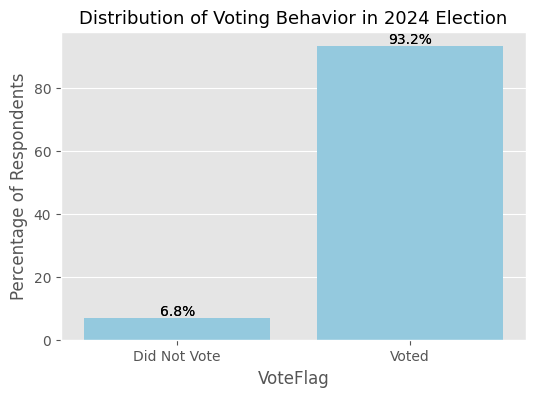

In [23]:
# bar plot of target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='VoteFlag', data=Voting_df, stat="percent")
ax = sns.countplot(x='VoteFlag', data=Voting_df, stat="percent", color='skyblue')
plt.ylabel('Percentage of Respondents', fontsize=12)
plt.title('Distribution of Voting Behavior in 2024 Election', fontsize=13, weight=400)
plt.xticks([0, 1], ['Did Not Vote', 'Voted'])
# add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10)

plt.show()

In [24]:
# Naive Model Selection
naive_features = [
    'VoterAge',
    'gender4',
    'educ',
    'race',
    'hispanic',
    'pid3', # Party ID
    'inputstate',
    'region',
    'student',
]

In [25]:
full_features = [
    #Target Variable
    'VoteFlag',
    
    # Copy from naive
    'VoterAge',         # Age (derived: 2024 - birthyr)
    'gender4',          # Gender
    'educ',             # Education
    'race',             # Race
    'hispanic',         # Hispanic
    'pid3',             # 3 point party ID
    'inputstate',       # State of Residence
    'region',           # Region
    'student',          # Student Full or Part-time

    # Multiracial categories
    "multrace_1",       # Multiracial - White
    "multrace_2",       # Multiracial - Black
    "multrace_3",       # Multiracial - Hispanic
    "multrace_4",       # Multiracial - Asian
    "multrace_5",       # Multiracial - Native American
    "multrace_8",       # Multiracial - Middle Eastern
    "multrace_97",      # Multiracial - Other
    "multrace_98",      # Multiracial - Don't know

    # Device & Registration
    'votereg',          # Voter Registration Status

    # Other
    'pid7',             # 7 point Party ID
    'immstat',          # Immigration background

    # Media consumption (past 24 hrs)
    "CC24_300_1",       # Media use past 24 hrs - Used social media
    "CC24_300_2",       # Media use past 24 hrs - Watched TV news
    "CC24_300_3",       # Media use past 24 hrs - Read a newspaper
    "CC24_300_4",       # Media use past 24 hrs - Listened to radio news
    "CC24_300_5",       # Media use past 24 hrs - None of these

    # Social media use in relation to politics
    "CC24_300d_1",      # Recent social media use - Posted a story, photo, video or link about politics
    "CC24_300d_2",      # Recent social media use - Posted a comment about politics
    "CC24_300d_3",      # Recent social media use - Read a story or watched a video about politics
    "CC24_300d_4",      # Recent social media use - Followed a political event
    "CC24_300d_5",      # Recent social media use - Forwarded a story, photo, video or link about politics to friends
    "CC24_300d_6",      # Recent social media use - None of the above

    # Economic perceptions
    "CC24_301",         # National Economics
    "CC24_302",         # Household income change
    "CC24_303",         # Price change in past year

    # Life changes
    "CC24_305_1",       # Life Changes - Married
    "CC24_305_2",       # Life Changes - Lost a job
    "CC24_305_3",       # Life Changes - Finished school
    "CC24_305_4",       # Life Changes - Retired
    "CC24_305_5",       # Life Changes - Divorced
    "CC24_305_6",       # Life Changes - Had a child
    "CC24_305_7",       # Life Changes - Taken a new job
    "CC24_305_9",       # Life Changes - Been a victim of a crime
    "CC24_305_10",      # Life Changes - Visited an emergency room
    "CC24_305_11",      # Life Changes - Visited a doctor for a regular examination
    "CC24_305_12",      # Life Changes - Received a raise at work
    "CC24_305_13",      # Life Changes - Had a pay cut at work
    "CC24_305_14",      # Life Changes - None of the above

    # Health status
    "CC24_309e",        # General health

    # Emergency expenses
    "CC24_309d_1",      # Emergency expense - Put it on credit card, pay off in full
    "CC24_309d_2",      # Emergency expense - Put it on credit card, pay off over time
    "CC24_309d_3",      # Emergency expense - With checking/savings or cash
    "CC24_309d_4",      # Emergency expense - Bank loan or line of credit
    "CC24_309d_5",      # Emergency expense - Borrowing from friend or family
    "CC24_309d_6",      # Emergency expense - Payday loan, deposit advance, or overdraft
    "CC24_309d_7",      # Emergency expense - By selling something
    "CC24_309d_8",      # Emergency expense - Wouldn't be able to pay right now

    # Knowledge of current politicians
    "CC24_310a",        # Know Party in Government - U.S. House of Representatives
    "CC24_310b",        # Know Party in Government - U.S. Senate

    # Voting habits
    #"CC24_363",         # Vote Intention
    # Removed at later stage due to data leakage 
    # (question allows users to note if they've already voted)

    # Miscellaneous
    "urbancity",        # Type of Area Living In
    "ideo5",            # Ideology
    "IsParent",         # Parent of any child either younger or older than 18 (derived)
    "employ",           # Employment Status
    "investor",         # Stock ownership
    "newsint",          # Political Interest
    "faminc_new",       # Family income
    "marstat",          # Marital Status
    "union",            # Labor union member
    "ownhome",          # Home ownership
    "industry",         # Industry of employment
    "jobnum",           # Number of jobs
    "sexuality",        # Sexual Orientation
    "transgender",      # Transgender

    # Religious habit
    "pew_religimp",     # Importance of religion (Pew version)
    "religpew",         # Religion

    # Election trust
    "CC24_421_1",       # Election fair - Elections in the U.S. are fair
    "CC24_421_2",       # Election fair - State/local government conducted fair and accurate election in 2024
    "CC24_423",         # Trust in federal government
    "CC24_424",         # Trust in state government

    # Past year political engagement
    "CC24_430a_1",      # Past year - Attend local political meetings
    "CC24_430a_2",      # Past year - Put up a political sign
    "CC24_430a_3",      # Past year - Work for a candidate or campaign
    "CC24_430a_4",      # Past year - Attend a political protest, march or demonstration
    "CC24_430a_5",      # Past year - Contact a public official
    "CC24_430a_6",      # Past year - Donate money to a candidate, campaign, or political organization
    "CC24_430a_7",      # Past year - Donate blood
    "CC24_430a_8",      # Past year - None of these

    # Money donation
    "CC24_430b_1",      # Donate money - Candidate for President
    "CC24_430b_2",      # Donate money - Candidate for U.S. Senate in my state
    "CC24_430b_3",      # Donate money - Candidate for U.S. Senate in another state
    "CC24_430b_4",      # Donate money - Candidate for U.S. House in my state
    "CC24_430b_5",      # Donate money - Candidate for U.S. House in another state
    "CC24_430b_6",      # Donate money - Candidate for state office
    "CC24_430b_7",      # Donate money - Political party committee
    "CC24_430b_8",      # Donate money - Political action committee at work
    "CC24_430b_9",      # Donate money - Political group
    "CC24_430b_10",     # Donate money - Other
    "CC24_430c",        # Donate money - total amount

    # Campaign contact
    "CC24_431a",        # Contacted by candidate or political campaign

    # Other post-election
    "gunown",           # Personal gun ownership
    "numchildren",      # Number of children
    "gigwork",          # Gig work
    "edloan",           # Student debtor

    # Voting history
    "presvote20post",   # 2020 President Vote Post Election
    "presvote16post",   # 2016 President Vote Post Election
]

In [26]:
# Index of truly numeric features (as opposed to categorical)
num_features = [
    "VoterAge",
    "faminc_new",
    "numchildren"
]

# Index of truly categorical features
cat_features = [x for x in full_features if x not in num_features]
cat_features.remove('VoteFlag') # Removing target variable

# Additionally create readable equivalents
num_readable = [CES2024_COLUMNS[x] for x in num_features]
cat_readable = [CES2024_COLUMNS[x] for x in cat_features]

In [27]:
filtered_df = Voting_df[full_features].astype('Int64') #Setting all to int to avoid later column naming errors

### Set Split & Undersampling
Voters (as opposed to nonvoters) are intensely overrepresented within the dataset. In the interest of countering this imbalance, we not only pursue a conventional 70 / 15 / 15 split (train / validation / test), but "undersample" the overrepresented class.

Despite the potential loss of information in regards to the majority target class through this method, trained models performed well on previously unseen data.

In [28]:
# Setting X & y
X = filtered_df.drop(columns=['VoteFlag'])
y = filtered_df['VoteFlag']

#Encoding
X_processed = pd.get_dummies(X, columns=cat_features, drop_first=False, dtype=int)

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

In [29]:
# Train-validation-test split (70 / 15 / 15)
X_pass, X_orig_test, y_pass, y_orig_test = train_test_split(X_scaled, y, test_size = 0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_orig_test, y_orig_test, test_size = 0.5, random_state = 42)

In [30]:
# Oversampling to correct for imbalance
rus = RandomUnderSampler(random_state=42)
X_train, y_train = rus.fit_resample(X_pass, y_pass)

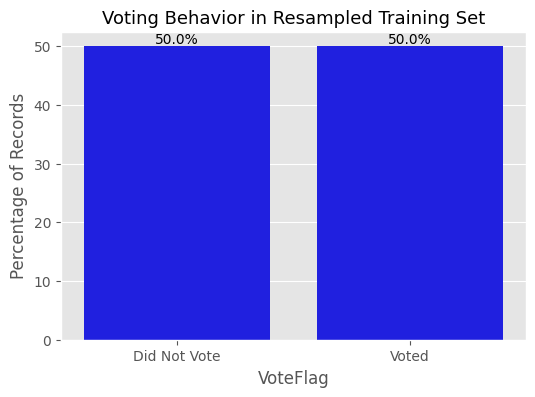

In [ ]:
# bar plot of target variable distribution in resampled set
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train, stat="percent", color='blue')
plt.ylabel('Percentage of Records', fontsize=12)
plt.title('Voting Behavior in Resampled Training Set', fontsize=13, weight=400)
plt.xticks([0, 1], ['Did Not Vote', 'Voted'])
# add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10)

plt.show()

## XGBoost
Given XGBoost's high capacity to handle categorical values (including those with NA entries), it provided a highly computational efficient method to process our dataset.

### Pre-Hyperparameter Tuning

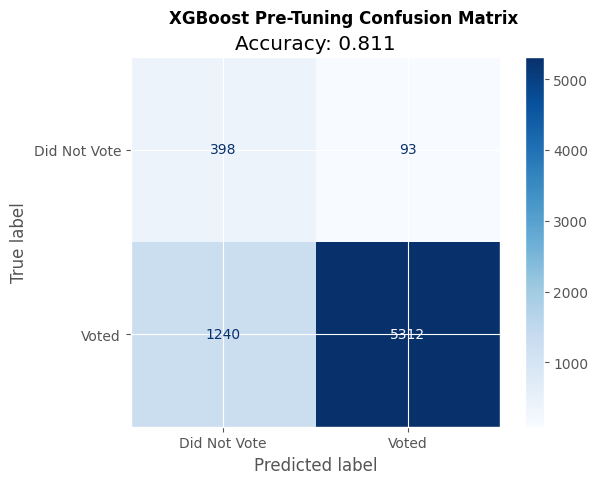

In [31]:
# Implementing XGBoost, initial demo
xgb_model = xgb.XGBClassifier(n_estimators = 40,
                              max_depth = 5,
                              scale_pos_weight = 1.0)
xgb_model.fit(X_train, y_train)

# Printing Confusion Matrix
y_pred = xgb_model.predict(X_val)
confusion_matrix_ex(y_val, y_pred, ["Did Not Vote", "Voted"], "XGBoost Pre-Tuning")

XGBoost Pre-Tuning Validation Accuracy: 0.8107340621894079
XGBoost Pre-Tuning Validation ROC-AUC: 0.886428857406454

Classification Report:
               precision    recall  f1-score   support

         0.0       0.24      0.81      0.37       491
         1.0       0.98      0.81      0.89      6552

    accuracy                           0.81      7043
   macro avg       0.61      0.81      0.63      7043
weighted avg       0.93      0.81      0.85      7043



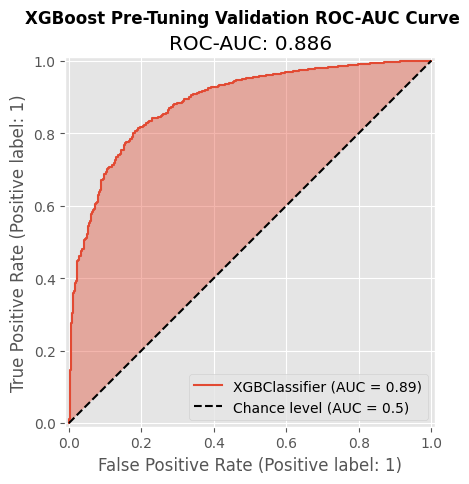

In [32]:
# Classification Report Output
perf_output(xgb_model, X_val, y_val, "XGBoost Pre-Tuning Validation")

In [33]:
# Defining the XGB Objective space
def xgb_objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }
    
    # initializing the XGBoost model
    test_model = xgb.XGBClassifier(**param)
    test_model.fit(X_train, y_train)
    # y_probs = test_model.predict_proba(X_val)[:, 1]
    y_f1 = test_model.predict(X_val)
    score = f1_score(y_val, y_f1, pos_label=0)   # F1 as optimization metric, 0 to maximize minority class F1
    return score

In [34]:
# Using Optuna to hyperparamter tune for XGBoost
xgb_study = optuna.create_study(study_name="xgboost_study", direction='maximize', sampler=opt_sampler) 
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True, n_jobs=-1)
xgb_best_params = xgb_study.best_params   

[I 2026-03-14 19:26:10,475] A new study created in memory with name: xgboost_study


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-14 19:26:24,229] Trial 17 finished with value: 0.37707247749881573 and parameters: {'max_depth': 8, 'learning_rate': 0.0836395566801705, 'n_estimators': 101, 'subsample': 0.8949435690023062, 'colsample_bytree': 0.7528552793105419, 'min_child_weight': 7, 'gamma': 4.330301665597129}. Best is trial 17 with value: 0.37707247749881573.
[I 2026-03-14 19:26:28,226] Trial 5 finished with value: 0.3819047619047619 and parameters: {'max_depth': 7, 'learning_rate': 0.09144493410079896, 'n_estimators': 250, 'subsample': 0.8525426611551824, 'colsample_bytree': 0.9785350848023158, 'min_child_weight': 10, 'gamma': 3.6797318011892406}. Best is trial 5 with value: 0.3819047619047619.
[I 2026-03-14 19:26:31,629] Trial 3 finished with value: 0.37952679864799616 and parameters: {'max_depth': 3, 'learning_rate': 0.060522824540039585, 'n_estimators': 288, 'subsample': 0.9098836044897434, 'colsample_bytree': 0.6032559122762973, 'min_child_weight': 3, 'gamma': 2.1517518820472032}. Best is trial 5 w

### Post-Hyperparameter Tuning


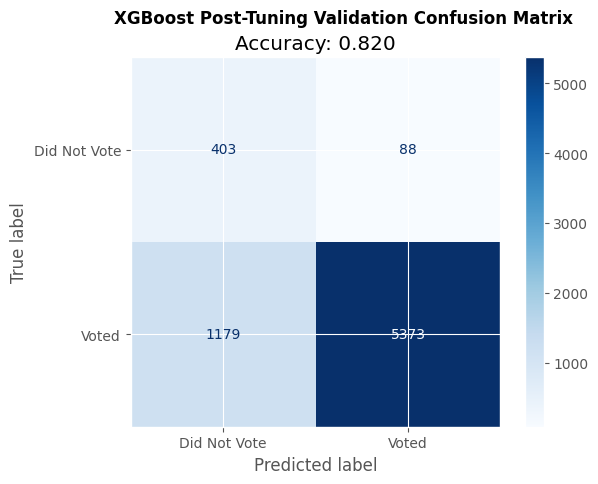

In [35]:
# Instatiating XGBoost using hyperparameter values
hyper_xgb = xgb.XGBClassifier(**xgb_best_params)
hyper_xgb.fit(X_train, y_train)

# Printing Confusion Matrix
y_pred = hyper_xgb.predict(X_val)
confusion_matrix_ex(y_val, y_pred, ["Did Not Vote", "Voted"], "XGBoost Post-Tuning Validation")

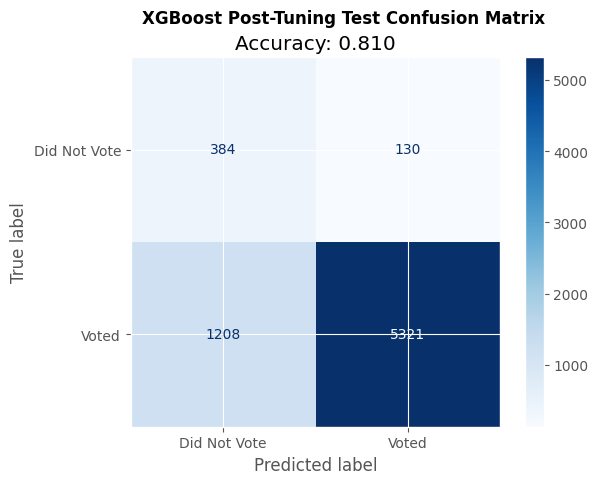

In [36]:
# Printing Testset Confusion Matrix
y_pred = hyper_xgb.predict(X_test)
confusion_matrix_ex(y_test, y_pred, ["Did Not Vote", "Voted"], "XGBoost Post-Tuning Test")

Hyperopt. XGB Validation Accuracy: 0.8201050688627005
Hyperopt. XGB Validation ROC-AUC: 0.8947371365904971

Classification Report:
               precision    recall  f1-score   support

         0.0       0.25      0.82      0.39       491
         1.0       0.98      0.82      0.89      6552

    accuracy                           0.82      7043
   macro avg       0.62      0.82      0.64      7043
weighted avg       0.93      0.82      0.86      7043



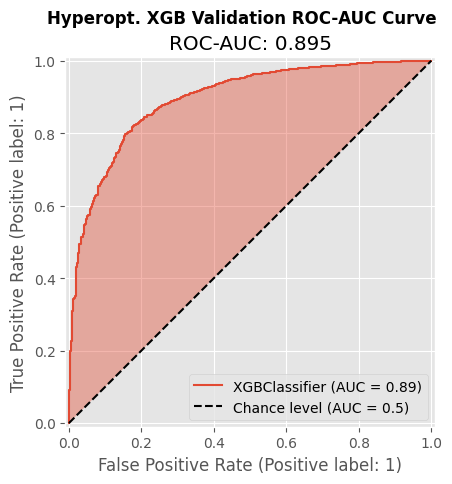

In [37]:
# Classification Report Output
perf_output(hyper_xgb, X_val, y_val, "Hyperopt. XGB Validation")

Hyperopt. XGB Test Accuracy: 0.8100241374414312
Hyperopt. XGB Test ROC-AUC: 0.8697320485138738

Classification Report:
               precision    recall  f1-score   support

         0.0       0.24      0.75      0.36       514
         1.0       0.98      0.81      0.89      6529

    accuracy                           0.81      7043
   macro avg       0.61      0.78      0.63      7043
weighted avg       0.92      0.81      0.85      7043



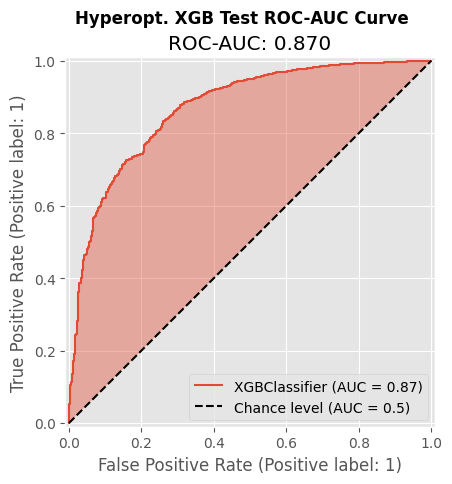

In [38]:
# Classification Report Output
perf_output(hyper_xgb, X_test, y_test, "Hyperopt. XGB Test")

### Feature Importance

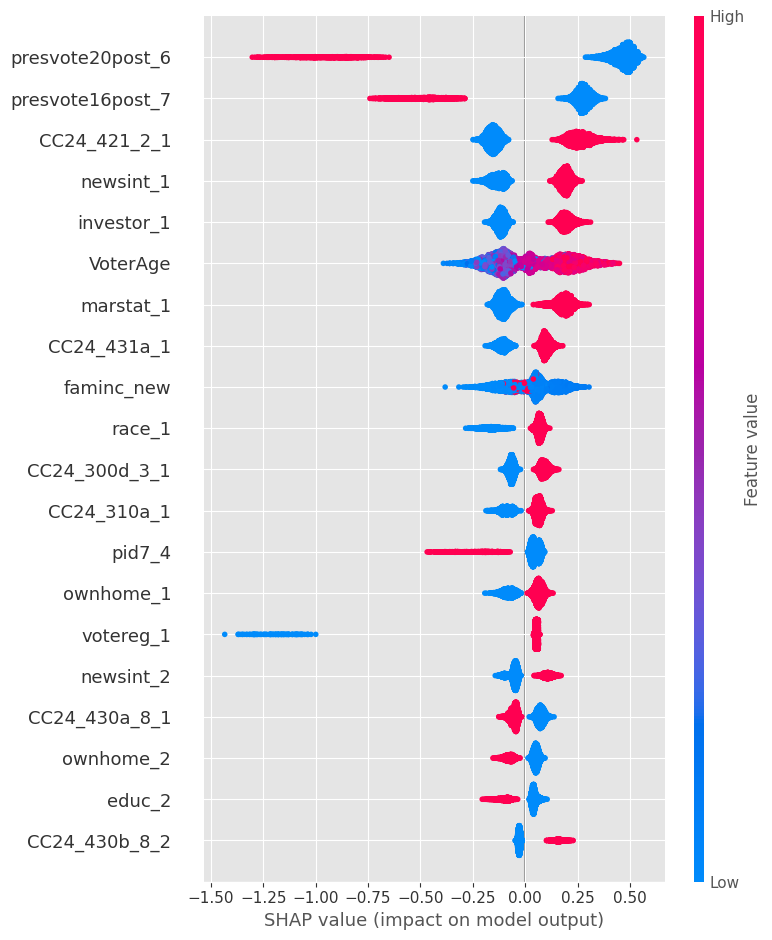

In [39]:
# SHAP-based explanation of behaviors (on test set)
explainer = shap.TreeExplainer(hyper_xgb)
shap_values = explainer(X_test)
shap_values.feature_names = X_processed.columns
shap.summary_plot(shap_values, X_test)

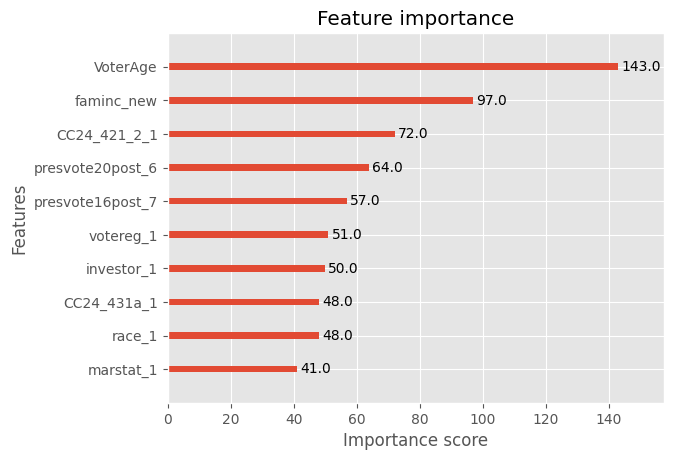

In [40]:
# XGBoost Internal Feature Importance
hyper_xgb.get_booster().feature_names = list(X_processed.columns)
plot_importance(hyper_xgb, max_num_features=10)
plt.show()

In [41]:
# Collecting model statistics
collect_stats(hyper_xgb, "XGBoost")

## Naive Bayes

### Basic prep of data to fit Naive Bayes requirements

In [42]:
# Given naive assumes categorical, make age buckets for modeling
filtered_df['voter_age_group'] = pd.cut(filtered_df['VoterAge'], bins=[17, 29, 44, 64, 130], labels=['18-29', '30-44', '45-64', '65+'])



In [43]:

# Get a basic idea of the naive dataset.
display(filtered_df[naive_features].head())


display(filtered_df["student"].value_counts())


,VoterAge,gender4,educ,race,hispanic,pid3,inputstate,region,student
0,46,2,2,2,0,1,42,1,<NA>
1,56,1,5,3,1,2,36,1,<NA>
2,78,2,4,1,0,3,42,1,<NA>
3,23,2,2,1,1,1,6,4,3
4,69,2,2,1,0,2,30,4,<NA>


student
1    1180
3     874
2     243
Name: count, dtype: Int64

In [44]:
# NA check
filtered_df[naive_features].isna().sum()

VoterAge          0
gender4           0
educ              0
race              0
hispanic          0
pid3              0
inputstate        0
region            0
student       44654
dtype: int64

In [45]:
# Data types
filtered_df[naive_features].dtypes

VoterAge      Int64
gender4       Int64
educ          Int64
race          Int64
hispanic      Int64
pid3          Int64
inputstate    Int64
region        Int64
student       Int64
dtype: object

In [46]:
# Create df for naive
# Remove student
naive_features = [feature for feature in naive_features if feature != 'student' and feature != 'VoterAge']  # cant properly deal with NAs given bayes assumptions

naive_features.append('voter_age_group') # Adding age bucket for naive model

# Create subset for baby version
naive_df = filtered_df[naive_features + ['VoteFlag']].copy()

In [47]:
# Verify alignment
display(naive_df.head())
naive_df.columns

,gender4,educ,race,hispanic,pid3,inputstate,region,voter_age_group,VoteFlag
0,2,2,2,0,1,42,1,45-64,1
1,1,5,3,1,2,36,1,45-64,1
2,2,4,1,0,3,42,1,65+,1
3,2,2,1,1,1,6,4,18-29,0
4,2,2,1,0,2,30,4,65+,1


Index(['gender4', 'educ', 'race', 'hispanic', 'pid3', 'inputstate', 'region',
       'voter_age_group', 'VoteFlag'],
      dtype='object')

## Baseline Model: Naive Bayes (Core Demographics)

> Build a compact benchmark model using a small set of high-signal demographic and political identity variables.

### Encoding Plan

> All baseline predictors are categorical, so features are ordinal-encoded before train/validation/test splits.

In [48]:
# Break into features and target
X = naive_df.drop(columns=['VoteFlag'])
Y = naive_df['VoteFlag']

# Check if Y is as expected
Y.value_counts()


# Pd_cut made age buckets, but need to encode
enc = OrdinalEncoder()
#
enc.set_output(transform="pandas")

X_encoded = enc.fit_transform(X)




In [49]:
# Understand value range - expect 0 indexed categoricals
X_encoded.describe()

,gender4,educ,race,hispanic,pid3,inputstate,region,voter_age_group
count,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000
mean,0.535857,2.782369,0.587911,0.089114,1.020724,24.872782,1.608294,1.993525
std,0.516962,1.462446,1.338326,0.284912,0.988376,14.843284,1.010605,0.921082
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,10.000000,1.000000,1.000000
50%,1.000000,3.000000,0.000000,0.000000,1.000000,25.000000,2.000000,2.000000
75%,1.000000,4.000000,0.000000,0.000000,2.000000,38.000000,2.000000,3.000000
max,3.000000,5.000000,7.000000,1.000000,4.000000,50.000000,3.000000,3.000000


In [50]:
# Review class imbalance from prior

Y.value_counts() / len(Y) * 100

VoteFlag
1    93.212072
0     6.787928
Name: count, dtype: Float64

In [51]:

# Train-validation-test split (70 / 15 / 15)
X_pass, X_orig_test, y_pass, y_orig_test = train_test_split(X_encoded, Y, test_size = 0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_orig_test, y_orig_test, test_size = 0.5, random_state = 42)

In [52]:
# Oversampling to correct for imbalance
rus = RandomUnderSampler()
X_train, y_train = rus.fit_resample(X_pass, y_pass)

In [53]:
# Define the model
bayes_model = CategoricalNB()

### Baseline Hyperparameter Tuning

> Tune `alpha` for `CategoricalNB` using cross-validated ROC-AUC, then evaluate the selected model on validation data.

In [54]:
# Create a grid of possible for Grid Search to test

param_grid_b = [
    {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 10.0]
    }
]

# Setup GridSearchCV
grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

# Fit and Results
grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END ........................alpha=0.01;, score=0.739 total time=   0.0s
[CV 2/3] END ........................alpha=0.01;, score=0.733 total time=   0.0s
[CV 3/3] END ........................alpha=0.01;, score=0.769 total time=   0.0s
[CV 1/3] END .........................alpha=0.1;, score=0.739 total time=   0.0s
[CV 2/3] END .........................alpha=0.1;, score=0.734 total time=   0.0s
[CV 3/3] END .........................alpha=0.1;, score=0.770 total time=   0.0s
[CV 1/3] END .........................alpha=0.5;, score=0.739 total time=   0.0s
[CV 2/3] END .........................alpha=0.5;, score=0.734 total time=   0.0s
[CV 3/3] END .........................alpha=0.5;, score=0.770 total time=   0.0s
[CV 1/3] END .........................alpha=1.0;, score=0.740 total time=   0.0s
[CV 2/3] END .........................alpha=1.0;, score=0.735 total time=   0.0s
[CV 3/3] END .........................alpha=1.0;,

In [55]:
## Second-Pass

# Create a grid of possible for Grid Search to test

param_grid_b = [
    {
        'alpha': [10, 20, 50, 70, 100, 250, 500, 750, 1000]
    }
]

# Setup GridSearchCV
grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

# Fit and Results
grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV 1/3] END ..........................alpha=10;, score=0.742 total time=   0.0s
[CV 2/3] END ..........................alpha=10;, score=0.739 total time=   0.0s
[CV 3/3] END ..........................alpha=10;, score=0.774 total time=   0.0s
[CV 1/3] END ..........................alpha=20;, score=0.744 total time=   0.0s
[CV 2/3] END ..........................alpha=20;, score=0.740 total time=   0.0s
[CV 3/3] END ..........................alpha=20;, score=0.775 total time=   0.0s
[CV 1/3] END ..........................alpha=50;, score=0.744 total time=   0.0s
[CV 2/3] END ..........................alpha=50;, score=0.742 total time=   0.0s
[CV 3/3] END ..........................alpha=50;, score=0.775 total time=   0.0s
[CV 1/3] END ..........................alpha=70;, score=0.743 total time=   0.0s
[CV 2/3] END ..........................alpha=70;, score=0.742 total time=   0.0s
[CV 3/3] END ..........................alpha=70;,

In [56]:
## Third Pass


# Create a grid of possible for Grid Search to test

param_grid_b = [
    {
        'alpha': [15, 20, 25, 30, 35, 40, 45, 50]#,
        #'fit_prior': [True, False],
    }
]


# Setup GridSearchCV
grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

# Fit and Results
grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3] END ..........................alpha=15;, score=0.743 total time=   0.0s
[CV 2/3] END ..........................alpha=15;, score=0.740 total time=   0.0s
[CV 3/3] END ..........................alpha=15;, score=0.774 total time=   0.0s
[CV 1/3] END ..........................alpha=20;, score=0.744 total time=   0.0s
[CV 2/3] END ..........................alpha=20;, score=0.740 total time=   0.0s
[CV 3/3] END ..........................alpha=20;, score=0.775 total time=   0.0s
[CV 1/3] END ..........................alpha=25;, score=0.744 total time=   0.0s
[CV 2/3] END ..........................alpha=25;, score=0.741 total time=   0.0s
[CV 3/3] END ..........................alpha=25;, score=0.775 total time=   0.0s
[CV 1/3] END ..........................alpha=30;, score=0.744 total time=   0.0s
[CV 2/3] END ..........................alpha=30;, score=0.741 total time=   0.0s
[CV 3/3] END ..........................alpha=30;,


Classification Report:
               precision    recall  f1-score   support

         0.0       0.15      0.65      0.24       491
         1.0       0.96      0.73      0.83      6552

    accuracy                           0.72      7043
   macro avg       0.56      0.69      0.54      7043
weighted avg       0.91      0.72      0.79      7043



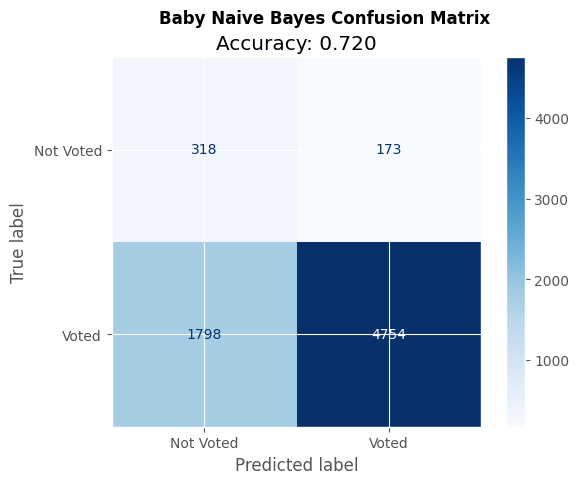

In [57]:
# classification report


# Predict
y_pred = grid_search_b.predict(X_val)

# Evaluate the model

print("\nClassification Report:\n", classification_report(y_val, y_pred))
# Printing Confusion Matrix for first pass
confusion_matrix_ex(y_val, y_pred, ["Not Voted", "Voted"], "Baby Naive Bayes")

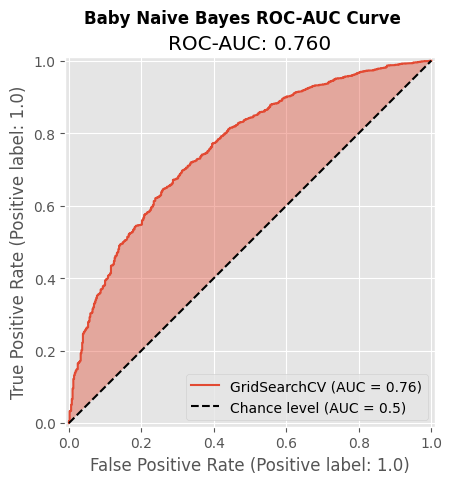

In [58]:
## ROC-AUC

roc_curve_display_ex(grid_search_b, X_val, y_val, y_topic = 'Baby Naive Bayes')

In [59]:
full_features = [
    # Copy from naive
    'voter_age_group',         # Age Buckets (derived: 2024 - birthyr and converted into buckets)
    'gender4',          # Gender
    'educ',             # Education
    'race',             # Race
    'hispanic',         # Hispanic
    'pid3',             # 3 point party ID
    'inputstate',       # State of Residence
    'region',           # Region
    #'student',          # Student Full or Part-time

    # Multiracial categories
    "multrace_1",       # Multiracial - White
    "multrace_2",       # Multiracial - Black
    "multrace_3",       # Multiracial - Hispanic
    "multrace_4",       # Multiracial - Asian
    "multrace_5",       # Multiracial - Native American
    "multrace_8",       # Multiracial - Middle Eastern
    "multrace_97",      # Multiracial - Other
    "multrace_98",      # Multiracial - Don't know

    # Device & Registration
    'votereg',          # Voter Registration Status

    # Other
    'pid7',             # 7 point Party ID
    'immstat',          # Immigration background

    # Media consumption (past 24 hrs) -- FE
    "CC24_300_1",       # Media use past 24 hrs - Used social media
    "CC24_300_2",       # Media use past 24 hrs - Watched TV news
    "CC24_300_3",       # Media use past 24 hrs - Read a newspaper
    "CC24_300_4",       # Media use past 24 hrs - Listened to radio news
    "CC24_300_5",       # Media use past 24 hrs - None of these

    # Social media use in relation to politics
    "CC24_300d_1",      # Recent social media use - Posted a story, photo, video or link about politics
    "CC24_300d_2",      # Recent social media use - Posted a comment about politics
    "CC24_300d_3",      # Recent social media use - Read a story or watched a video about politics
    "CC24_300d_4",      # Recent social media use - Followed a political event
    "CC24_300d_5",      # Recent social media use - Forwarded a story, photo, video or link about politics to friends
    "CC24_300d_6",      # Recent social media use - None of the above

    # Economic perceptions
    "CC24_301",         # National Economics
    "CC24_302",         # Household income change
    "CC24_303",         # Price change in past year

    # Health status
    "CC24_309e",        # General health

    # Emergency expenses
    "CC24_309d_1",      # Emergency expense - Put it on credit card, pay off in full
    "CC24_309d_2",      # Emergency expense - Put it on credit card, pay off over time
    "CC24_309d_3",      # Emergency expense - With checking/savings or cash
    "CC24_309d_4",      # Emergency expense - Bank loan or line of credit
    "CC24_309d_5",      # Emergency expense - Borrowing from friend or family
    "CC24_309d_6",      # Emergency expense - Payday loan, deposit advance, or overdraft
    "CC24_309d_7",      # Emergency expense - By selling something
    "CC24_309d_8",      # Emergency expense - Wouldn't be able to pay right now

    # Knowledge of current politicians
    "CC24_310a",        # Know Party in Government - U.S. House of Representatives
    "CC24_310b",        # Know Party in Government - U.S. Senate

    # Voting habits
    #"CC24_363",         # Vote Intention - drop bc of data leakage from early voting

    # Miscellaneous
    "urbancity",        # Type of Area Living In
    "ideo5",            # Ideology
    #"parent_97",           # Parent of child younger or older than 18
    "employ",           # Employment Status
    "investor",            # Stock ownership
    "newsint",          # Political Interest
    #"faminc_new",       # Family income
    "marstat",          # Marital Status
    "union",            # Labor union member
    "ownhome",          # Home ownership
    "industry",         # Industry of employment
    "jobnum",           # Number of jobs
    "sexuality",        # Sexual Orientation
    "transgender",      # Transgender

    # Religious habit
    "pew_religimp",     # Importance of religion (Pew version)
    "religpew",         # Religion

    # Election habits
    "CC24_421_1",       # Election fair - Elections in the U.S. are fair
    "CC24_421_2",       # Election fair - State/local government conducted fair and accurate election in 2024
    "CC24_423",         # Trust in federal government
    "CC24_424",         # Trust in state government

    # Past year political engagement
    "CC24_430a_1",      # Past year - Attend local political meetings
    "CC24_430a_2",      # Past year - Put up a political sign
    "CC24_430a_3",      # Past year - Work for a candidate or campaign
    "CC24_430a_4",      # Past year - Attend a political protest, march or demonstration
    "CC24_430a_5",      # Past year - Contact a public official
    "CC24_430a_6",      # Past year - Donate money to a candidate, campaign, or political organization
    "CC24_430a_7",      # Past year - Donate blood
    "CC24_430a_8",      # Past year - None of these

    # Money donation
    "CC24_430b_1",      # Donate money - Candidate for President
    "CC24_430b_2",      # Donate money - Candidate for U.S. Senate in my state
    "CC24_430b_3",      # Donate money - Candidate for U.S. Senate in another state
    "CC24_430b_4",      # Donate money - Candidate for U.S. House in my state
    "CC24_430b_5",      # Donate money - Candidate for U.S. House in another state
    "CC24_430b_6",      # Donate money - Candidate for state office
    "CC24_430b_7",      # Donate money - Political party committee
    "CC24_430b_8",      # Donate money - Political action committee at work
    "CC24_430b_9",      # Donate money - Political group
    "CC24_430b_10",     # Donate money - Other
    "CC24_430c",        # Donate money - total amount

    # Campaign contact
    "CC24_431a",        # Contacted by candidate or political campaign

    # Other post-election
    "gunown",           # Personal gun ownership
    #"numchildren",      # Number of children
    "gigwork",          # Gig work
    "edloan",           # Student debtor

    # Voting history
    "presvote20post",   # 2020 President Vote Post Election
    "presvote16post",   # 2016 President Vote Post Election

    # Parent variable
    "IsParent"
]

In [60]:
# Check parent values to understand if it's an accurate parent flag
filtered_df['IsParent'].value_counts()

IsParent
1    28325
0    18626
Name: count, dtype: Int64

In [61]:
full_df = filtered_df[full_features + ['VoteFlag']].copy()


full_df.shape

(46951, 89)

In [62]:
# Review NAs
(full_df.isna().sum() / len(full_df) * 100).sort_values(ascending = False)

CC24_430c      76.294435
CC24_430b_5    75.849290
CC24_430b_9    75.849290
CC24_430b_8    75.849290
CC24_430b_1    75.849290
                 ...    
CC24_430a_7     0.000000
CC24_430a_4     0.000000
CC24_430a_1     0.000000
IsParent        0.000000
VoteFlag        0.000000
Length: 89, dtype: float64

In [63]:
## Previous vote

display(full_df['presvote20post'].value_counts(dropna=False))
display(full_df['presvote16post'].value_counts(dropna=False))

# 0 if did not vote, else 1; NA counts as not matching
full_df['always_voted'] = (
    ~(
        full_df['presvote20post'].eq(6).fillna(False)
        & full_df['presvote16post'].eq(7).fillna(False)
    )
).astype(int)

display(full_df['always_voted'].value_counts())



presvote20post
1       22729
2       17448
6        5388
3         664
5         489
4         211
<NA>       22
Name: count, dtype: Int64

presvote16post
1       18056
2       16437
7        9183
3        1470
6         773
4         745
5         254
<NA>       33
Name: count, dtype: Int64

always_voted
1    42754
0     4197
Name: count, dtype: int64

In [64]:

## Money Donations - categorical end goal

# Review money donation column to understand data structure - looks like CC23_430c, or total amount, should sum to the b's
full_df[['CC24_430c', 'CC24_430b_1', 'CC24_430b_2', 'CC24_430b_3', 'CC24_430b_4']].head(20)

# Create binary
full_df['money_donation'] = full_df['CC24_430c'].notna().astype(int)

# Delete original columns - b is sub questions
full_df.drop(columns=full_df.filter(regex='CC24_430b_|CC24_430c'), inplace=True)




In [65]:
## Job Num
# Drop jobnum because employ captures the categorical variation of this

full_df.drop(columns=['jobnum'], inplace = True)

In [66]:
## edloan - 1 is yes loan, 2 is no loan, NA is non student

full_df['edloan'].value_counts()

# Replace to create 1 if yes loan, 0 if not (students AND non-students)
full_df['student_debt'] = full_df['edloan'].apply(lambda x: 1 if x == 1 else 0)

# Drop edloan

full_df.drop(columns=['edloan'], inplace = True)

In [67]:
## Social Media usage - Political COmmunication - CC24_300d_N
# This is a subset of social media users. NAs mean  non-social media use in past 24 hours
# Goal: 1 = used political social media, 0 = did not use political social media (including non social media users)

# Review values
display(full_df['CC24_300d_6'].value_counts(dropna=False))


# Create new variable
# Is null for for non social media users and x == 1 is for none of the above
full_df['political_media_user'] = full_df['CC24_300d_6'].apply(lambda x: 0 if pd.isnull(x) or x == 1 else 1)


# Drop original variables (all CC23_300d_N)
full_df.drop(columns=full_df.filter(regex='CC24_300d_').columns, inplace=True)





CC24_300d_6
2       26528
1       11050
<NA>     9373
Name: count, dtype: Int64

In [68]:
"""  
# â”€â”€ Past year political activities (check all) â”€â”€
    "CC24_430a_1": "Past year - Attend local political meetings",
    "CC24_430a_2": "Past year - Put up a political sign",
    "CC24_430a_3": "Past year - Work for a candidate or campaign",
    "CC24_430a_4": "Past year - Attend a political protest, march or demonstration",
    "CC24_430a_5": "Past year - Contact a public official",
    "CC24_430a_6": "Past year - Donate money to a candidate, campaign, or political organization",
    "CC24_430a_7": "Past year - Donate blood",
    "CC24_430a_8": "Past year - None of these",


"""

## 1 is yes, 2 is no


# Create new variable for any political activity in past year
full_df['past_year_civic_engagement'] = full_df[[
    "CC24_430a_1",
    "CC24_430a_2",
    "CC24_430a_3",
    "CC24_430a_4",
    "CC24_430a_5",
    "CC24_430a_6",
    "CC24_430a_7",
]].apply(lambda x: 1 if x.eq(1).any() else 0, axis=1)

# Drop original variables
full_df.drop(columns=full_df.filter(regex='CC24_430a_').columns, inplace=True)



In [69]:
# Do mode inputat



# Remaining NAs - get column names that still have NA
na_cols = full_df.columns[full_df.isna().any()].tolist()

# Inpute
imputer = SimpleImputer(strategy='most_frequent')
full_df[na_cols] = imputer.fit_transform(full_df[na_cols])

## Expanded Model Training and Evaluation

> Encode, split, tune, and evaluate the full-feature Naive Bayes pipeline using the same evaluation framework as the baseline model.

In [70]:
# Which columns are float and string
float_cols = full_df.select_dtypes(include=['float64']).columns.tolist()
object_cols = full_df.select_dtypes(include=['object']).columns.tolist()
print("Float columns:", float_cols)
print("Object columns:", object_cols)


# Check if any of the float columns have decimal values or if they are actually categorical variables that should be converted to int
for col in float_cols:
    unique_values = full_df[col].dropna().unique()
    print(f"Column: {col}, Unique Values: {unique_values}")

# Convert all float columns to int
# This is because they are all categorical variables that were read in as float due to the presence of NaNs, but we have imputed those NaNs and they should be integers
for col in float_cols:
    full_df[col] = full_df[col].astype(int)    

Float columns: ['multrace_97', 'immstat', 'CC24_301', 'CC24_302', 'CC24_303', 'CC24_309e', 'CC24_310a', 'CC24_310b', 'urbancity', 'ideo5', 'employ', 'investor', 'newsint', 'marstat', 'union', 'ownhome', 'industry', 'sexuality', 'transgender', 'pew_religimp', 'religpew', 'CC24_421_1', 'CC24_421_2', 'CC24_423', 'CC24_424', 'CC24_431a', 'gunown', 'gigwork', 'presvote20post', 'presvote16post']
Object columns: []
Column: multrace_97, Unique Values: [2.]
Column: immstat, Unique Values: [5. 4. 3. 1.]
Column: CC24_301, Unique Values: [3. 1. 5. 2. 6. 4.]
Column: CC24_302, Unique Values: [3. 2. 4. 5. 1.]
Column: CC24_303, Unique Values: [3. 2. 4. 1. 5.]
Column: CC24_309e, Unique Values: [1. 2. 4. 3. 5.]
Column: CC24_310a, Unique Values: [4. 1. 2. 3.]
Column: CC24_310b, Unique Values: [4. 2. 1. 3.]
Column: urbancity, Unique Values: [1. 2. 3. 4. 5.]
Column: ideo5, Unique Values: [3. 4. 1. 2. 6. 5.]
Column: employ, Unique Values: [6. 1. 5. 4. 3. 2. 7. 9. 8.]
Column: investor, Unique Values: [ 2. 99

In [71]:
# Break into features and target
X = full_df.drop(columns=['VoteFlag'])
Y = full_df['VoteFlag']

# Pd_cut made age buckets, but need to encode
enc = OrdinalEncoder()
enc.set_output(transform="pandas")

X_encoded = enc.fit_transform(X)

In [72]:
# Understand value range - check for 0 indexing
X_encoded.describe()

,voter_age_group,gender4,educ,race,hispanic,pid3,inputstate,region,multrace_1,multrace_2,...,gunown,gigwork,presvote20post,presvote16post,IsParent,always_voted,money_donation,student_debt,political_media_user,past_year_civic_engagement
count,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,...,46951.000000,46951.000000,46951.000000,46951.00000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000,46951.000000
mean,1.993525,0.535857,2.782369,0.587911,0.089114,1.020724,24.872782,1.608294,0.686546,0.955060,...,1.399566,0.863134,1.028839,1.73779,0.603289,0.910609,0.237056,0.096547,0.565015,0.485016
std,0.921082,0.516962,1.462446,1.338326,0.284912,0.988376,14.843284,1.010605,0.463902,0.207176,...,0.934605,0.343710,1.563896,2.26663,0.489220,0.285310,0.425281,0.295344,0.495760,0.499781
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,3.000000,0.000000,0.000000,1.000000,25.000000,2.000000,1.000000,1.000000,...,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,3.000000,1.000000,4.000000,0.000000,0.000000,2.000000,38.000000,2.000000,1.000000,1.000000,...,2.000000,1.000000,1.000000,2.00000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,3.000000,3.000000,5.000000,7.000000,1.000000,4.000000,50.000000,3.000000,1.000000,1.000000,...,3.000000,1.000000,5.000000,6.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [73]:
# Train-validation-test split (70 / 15 / 15)
X_pass, X_orig_test, y_pass, y_orig_test = train_test_split(X_encoded, Y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_orig_test, y_orig_test, test_size=0.5, random_state=42)

In [74]:
# Undersample majority class to balance training data
rus = RandomUnderSampler(random_state=42)
X_train, y_train = rus.fit_resample(X_pass, y_pass)

In [75]:
# Review class imbalance post-undersmapler
y_train.value_counts() / len(Y) * 100

VoteFlag
0    4.647398
1    4.647398
Name: count, dtype: Float64

In [76]:
# Define the model
# min_categories ensures CategoricalNB allocates enough category slots per feature
# even when a CV fold's training split is missing rare category values
min_cats = (X_encoded.max() + 1).astype(int).tolist()

# Set class prior to an even 50/50 baseline
bayes_model = CategoricalNB(class_prior=[0.5, 0.5], min_categories=min_cats)

### Expanded Hyperparameter Tuning

> Repeat grid search on `alpha` for the expanded feature matrix to maximize validation ROC-AUC.

In [77]:
# Pass 1

param_grid_b = [
    {
        'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 10.0]
    }
]

grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END ........................alpha=0.01;, score=0.875 total time=   0.0s
[CV 2/3] END ........................alpha=0.01;, score=0.873 total time=   0.0s
[CV 3/3] END ........................alpha=0.01;, score=0.880 total time=   0.0s
[CV 1/3] END .........................alpha=0.1;, score=0.876 total time=   0.0s
[CV 2/3] END .........................alpha=0.1;, score=0.873 total time=   0.0s
[CV 3/3] END .........................alpha=0.1;, score=0.880 total time=   0.0s
[CV 1/3] END .........................alpha=0.5;, score=0.876 total time=   0.0s
[CV 2/3] END .........................alpha=0.5;, score=0.873 total time=   0.0s
[CV 3/3] END .........................alpha=0.5;, score=0.879 total time=   0.0s
[CV 1/3] END .........................alpha=1.0;, score=0.876 total time=   0.0s
[CV 2/3] END .........................alpha=1.0;, score=0.873 total time=   0.0s
[CV 3/3] END .........................alpha=1.0;,

In [78]:
# Pass 2
param_grid_b = [
    {
        'alpha': [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
    }
]

grid_search_b = GridSearchCV(
    estimator=bayes_model,
    param_grid=param_grid_b,
    cv=3,
    scoring='roc_auc',
    refit=True,
    verbose=3
)

grid_search_b.fit(X_train, y_train)

print(f"Best Params: {grid_search_b.best_params_}")
gs_results_b = grid_search_b.cv_results_

Fitting 3 folds for each of 7 candidates, totalling 21 fits
[CV 1/3] END ........................alpha=0.05;, score=0.876 total time=   0.0s
[CV 2/3] END ........................alpha=0.05;, score=0.873 total time=   0.0s
[CV 3/3] END ........................alpha=0.05;, score=0.880 total time=   0.0s
[CV 1/3] END .........................alpha=0.1;, score=0.876 total time=   0.0s
[CV 2/3] END .........................alpha=0.1;, score=0.873 total time=   0.0s
[CV 3/3] END .........................alpha=0.1;, score=0.880 total time=   0.0s
[CV 1/3] END ........................alpha=0.15;, score=0.876 total time=   0.0s
[CV 2/3] END ........................alpha=0.15;, score=0.873 total time=   0.0s
[CV 3/3] END ........................alpha=0.15;, score=0.880 total time=   0.0s
[CV 1/3] END .........................alpha=0.2;, score=0.876 total time=   0.0s
[CV 2/3] END .........................alpha=0.2;, score=0.873 total time=   0.0s
[CV 3/3] END .........................alpha=0.2;,


Classification Report:
               precision    recall  f1-score   support

         0.0       0.22      0.79      0.35       491
         1.0       0.98      0.79      0.88      6552

    accuracy                           0.79      7043
   macro avg       0.60      0.79      0.61      7043
weighted avg       0.93      0.79      0.84      7043



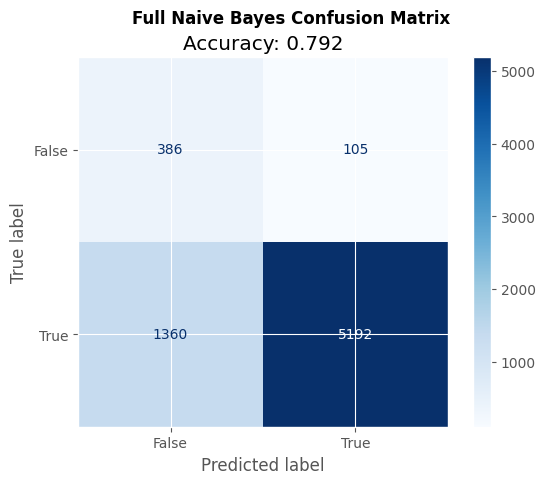

In [79]:

# classification report


# Predict
y_pred = grid_search_b.predict(X_val)

# Evaluate the model

print("\nClassification Report:\n", classification_report(y_val, y_pred))
# Printing Confusion Matrix for first pass
confusion_matrix_ex(y_val, y_pred, ["False", "True"], "Full Naive Bayes")

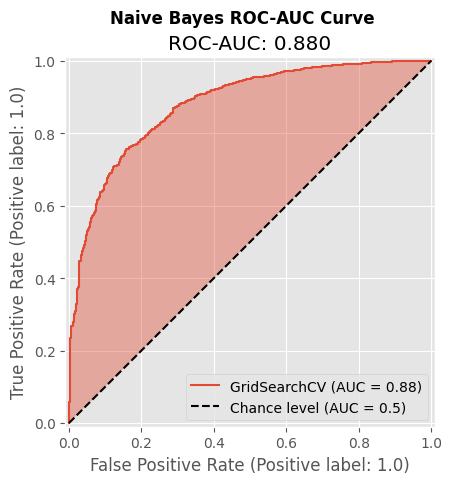

In [80]:
## ROC-AUC

roc_curve_display_ex(grid_search_b, X_val, y_val, y_topic = 'Naive Bayes')

## Model Interpretation

> Interpret the tuned model with two views:
- global ranking via log-probability deltas (feature importance)
- local/global effect patterns via SHAP summaries

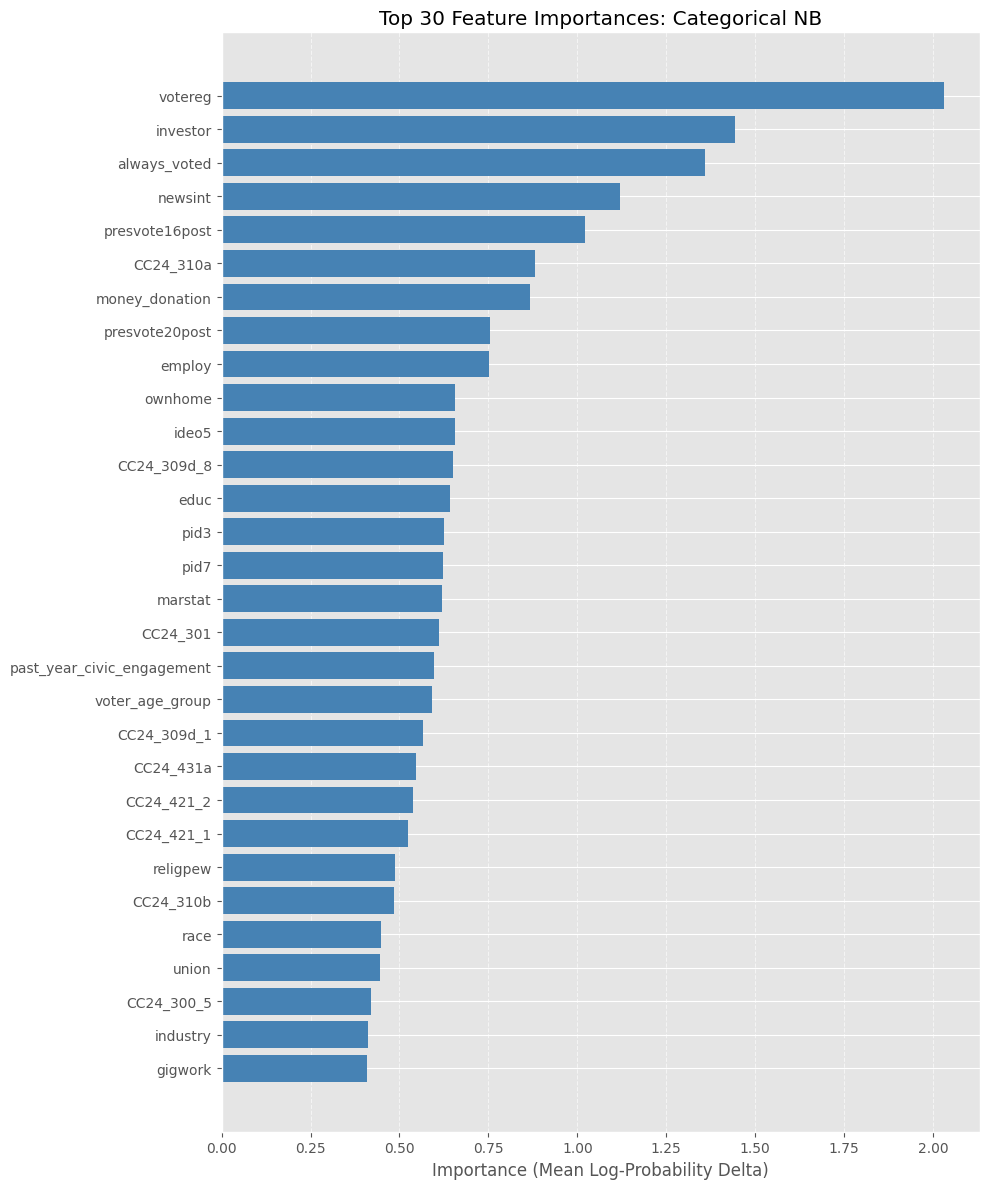

In [81]:
# 1. Access the underlying model from the GridSearch object
best_model = grid_search_b.best_estimator_

importances = []
for i in range(len(X.columns)):
    # Access the log probabilities from the best estimator
    log_probs = best_model.feature_log_prob_[i]
    
    # Calculate the average magnitude of the difference between class 0 (No Vote) and 1 (Vote)
    # This measures how much this feature discriminates between the two outcomes
    diff = np.mean(np.abs(log_probs[0] - log_probs[1]))
    importances.append(diff)

# 2. Prepare Data for Plotting
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 3. Graphing
# Since you have 90 features, showing just the top 30 makes the chart readable
top_n = 30
plot_data = feat_importance.tail(top_n)

plt.figure(figsize=(10, 12)) 
plt.barh(plot_data['Feature'], plot_data['Importance'], color='steelblue')
plt.xlabel('Importance (Mean Log-Probability Delta)')
plt.title(f'Top {top_n} Feature Importances: Categorical NB')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

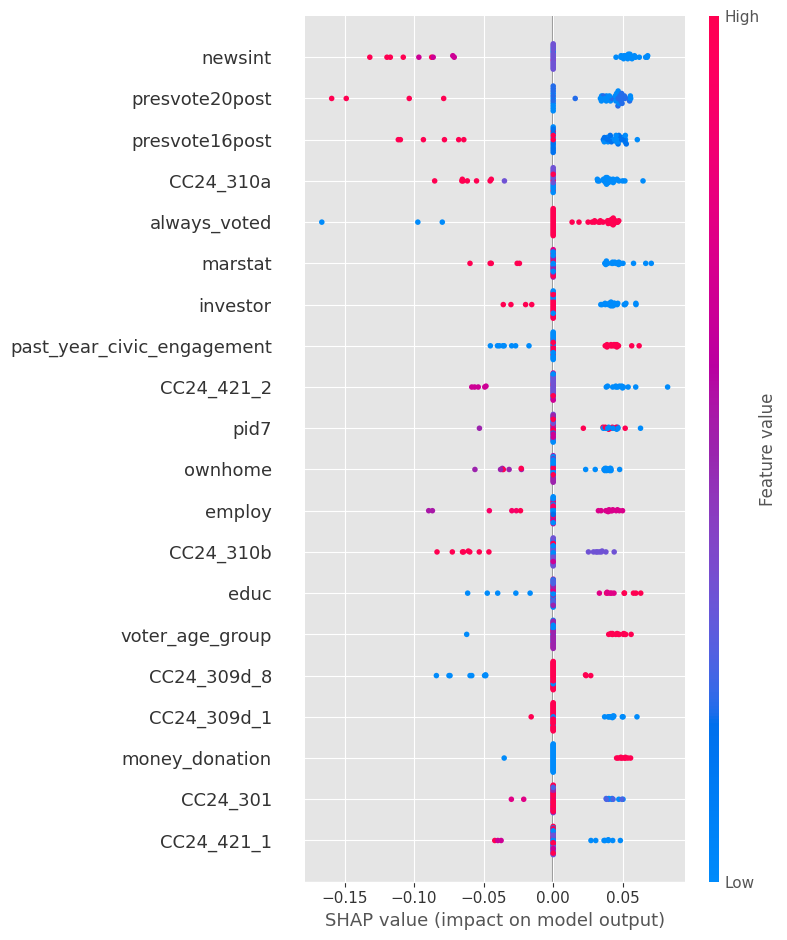

In [82]:
# Use the fitted full Naive Bayes model from the grid search
best_model = grid_search_b.best_estimator_

# Sample rows with shap.sample for a tractable KernelExplainer run
background_data = shap.sample(X_train, 100, random_state=42)
explain_data = shap.sample(X_val, 50, random_state=42)

explainer = shap.KernelExplainer(best_model.predict_proba, background_data)
shap_values = explainer.shap_values(explain_data)

# SHAP returns either a list per class or a 3D array depending on version
if isinstance(shap_values, list):
    class_1_values = shap_values[1]
elif getattr(shap_values, 'ndim', None) == 3:
    class_1_values = shap_values[:, :, 1]
else:
    class_1_values = shap_values

shap.summary_plot(class_1_values, explain_data, feature_names=explain_data.columns)

## Final Test
Running model on test set


Classification Report:
               precision    recall  f1-score   support

         0.0       0.22      0.74      0.35       514
         1.0       0.98      0.80      0.88      6529

    accuracy                           0.79      7043
   macro avg       0.60      0.77      0.61      7043
weighted avg       0.92      0.79      0.84      7043



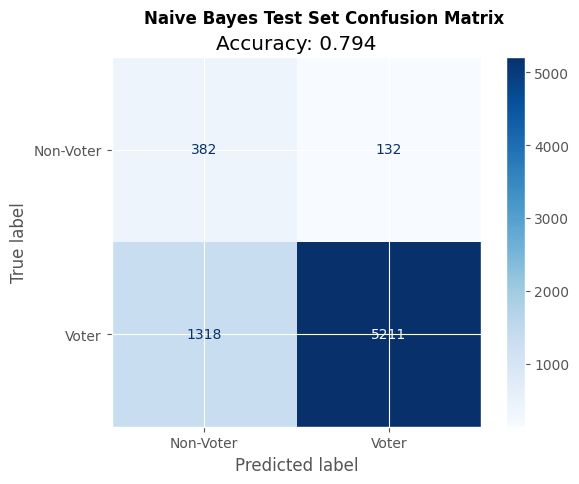

In [83]:
# Classification Report on Test


# Predict
y_pred = grid_search_b.predict(X_test)

# Evaluate the model

print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Printing Confusion Matrix for first pass
confusion_matrix_ex(y_test, y_pred, ["Non-Voter", "Voter"], "Naive Bayes Test Set")

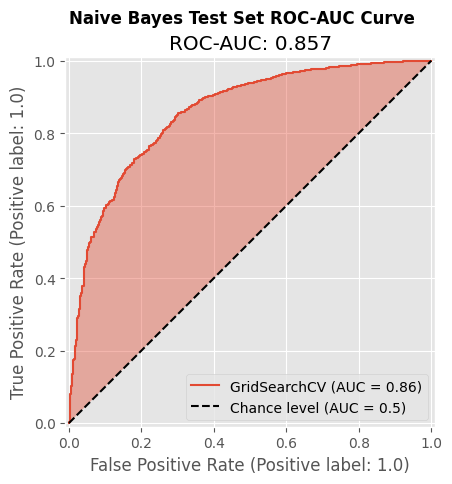

In [84]:
# ROC-AUC Curve
roc_curve_display_ex(grid_search_b, X_test, y_test, y_topic='Naive Bayes Test Set')

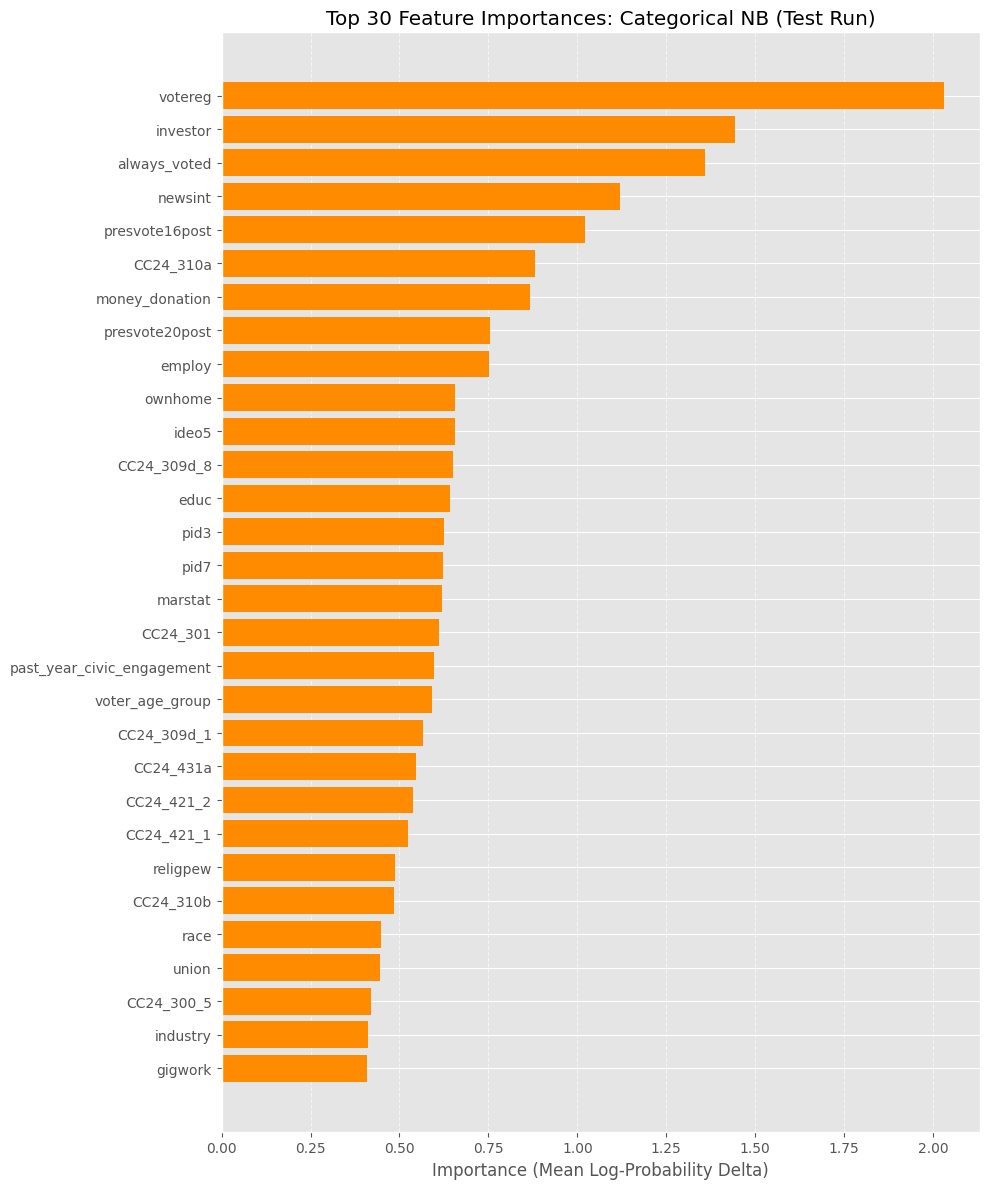

In [85]:
# Feature Importance using the tuned model evaluated on the test split
best_model = grid_search_b.best_estimator_

test_importances = []
for i in range(len(X.columns)):
    log_probs = best_model.feature_log_prob_[i]
    diff = np.mean(np.abs(log_probs[0] - log_probs[1]))
    test_importances.append(diff)

test_feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': test_importances
}).sort_values(by='Importance', ascending=True)

top_n = 30
test_plot_data = test_feat_importance.tail(top_n)

plt.figure(figsize=(10, 12))
plt.barh(test_plot_data['Feature'], test_plot_data['Importance'], color='darkorange')
plt.xlabel('Importance (Mean Log-Probability Delta)')
plt.title(f'Top {top_n} Feature Importances: Categorical NB (Test Run)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

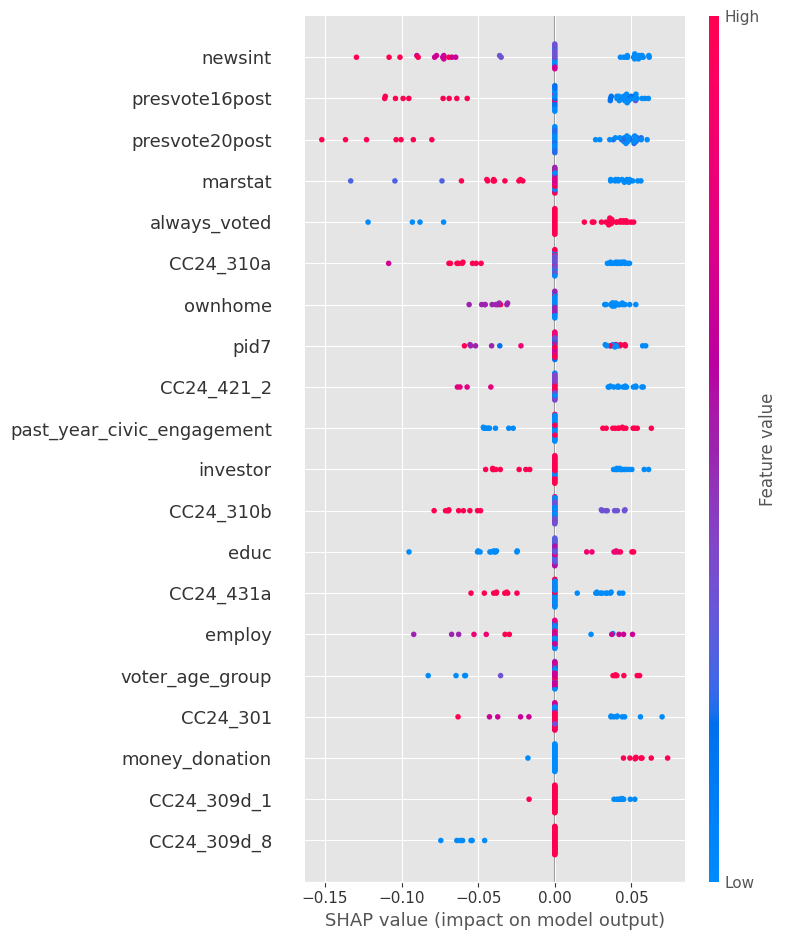

In [86]:
# SHAP summary for the test split
best_model = grid_search_b.best_estimator_

test_background_data = shap.sample(X_train, 100, random_state=42)
test_explain_data = shap.sample(X_test, 50, random_state=42)

test_explainer = shap.KernelExplainer(best_model.predict_proba, test_background_data)
test_shap_values = test_explainer.shap_values(test_explain_data)

if isinstance(test_shap_values, list):
    test_class_1_values = test_shap_values[1]
elif getattr(test_shap_values, 'ndim', None) == 3:
    test_class_1_values = test_shap_values[:, :, 1]
else:
    test_class_1_values = test_shap_values

shap.summary_plot(test_class_1_values, test_explain_data, feature_names=test_explain_data.columns)

In [87]:
# Collecting model statistics
collect_stats(best_model, "Naive Bayes")

# CatBoost

## Naive Model

As a starting place, using basic, easy to obtain information to predict turnout.

In [88]:
# selecting features for a naive model based on common predictors of voting behavior

naive_features = [
    'VoterAge',
    'gender4',
    'educ',
    'race',
    'hispanic',
    'pid3', # Party ID
    'inputstate',
    'region',
    'is_student',
]

In [89]:
# make df for naive model
naive_df = Voting_df[naive_features]
naive_df.head()

,VoterAge,gender4,educ,race,hispanic,pid3,inputstate,region,is_student
0,46,2,2,2,0,1,42,1,0
1,56,1,5,3,1,2,36,1,0
2,78,2,4,1,0,3,42,1,0
3,23,2,2,1,1,1,6,4,0
4,69,2,2,1,0,2,30,4,0


In [90]:
# identify categorical and numerical features
categorical_features = ['gender4', 'educ', 'race', 'hispanic', 'pid3', 'inputstate', 'region', 'is_student']
numerical_features = ['VoterAge']

In [91]:
# set X and Y
X = Voting_df[naive_features]
y = Voting_df['VoteFlag'].astype(int) # cat prefers 0/1 over bool, convert target to binary

# train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [92]:
# build initial model
naive_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

# fit model
naive_model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	test: 0.5314729	best: 0.5314729 (0)	total: 170ms	remaining: 2m 49s
100:	test: 0.7850935	best: 0.7851742 (97)	total: 15.3s	remaining: 2m 15s
200:	test: 0.7865158	best: 0.7866406 (187)	total: 39.7s	remaining: 2m 37s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.786689395
bestIteration = 244

Shrink model to first 245 iterations.


CatBoostClassifier(cat_features=['gender4', 'educ', 'race', 'hispanic', 'pid3', 'inputstate', 'region', 'is_student'], depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.05, random_seed=42, verbose=100)

In [93]:
# evaluate model
y_pred = naive_model.predict(X_test)
y_prob = naive_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.57      0.05      0.08       637
           1       0.93      1.00      0.97      8754

    accuracy                           0.93      9391
   macro avg       0.75      0.52      0.52      9391
weighted avg       0.91      0.93      0.91      9391

ROC-AUC: 0.7867


As predicted, the model had very low recall for non-voters (0.05). This is because of the large imbalance on voters and non-voters in the dataset.

In [94]:
# look at feature importance
feat_imp = pd.Series(naive_model.get_feature_importance(), index=naive_features).sort_values(ascending=False)
print("\nFeature Importances:")
print(feat_imp)


Feature Importances:
educ          26.466265
VoterAge      24.465923
pid3          14.685769
race           9.719818
inputstate     8.574324
gender4        7.863877
region         5.253702
hispanic       1.683908
is_student     1.286416
dtype: float64


### Trying again, accounting for class balance

In [95]:
# build model
naive_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_features,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100,
    # add class weights to address imbalance in target variable
    auto_class_weights='Balanced'
)

# fit model
naive_model.fit(X_train, y_train, eval_set=(X_test, y_test))

# evaluate model
y_pred = naive_model.predict(X_test)
y_prob = naive_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


0:	test: 0.7456453	best: 0.7456453 (0)	total: 188ms	remaining: 3m 8s
100:	test: 0.7881756	best: 0.7881756 (99)	total: 22s	remaining: 3m 15s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7881755961
bestIteration = 99

Shrink model to first 100 iterations.
              precision    recall  f1-score   support

           0       0.17      0.69      0.27       637
           1       0.97      0.75      0.84      8754

    accuracy                           0.74      9391
   macro avg       0.57      0.72      0.56      9391
weighted avg       0.92      0.74      0.81      9391

ROC-AUC: 0.7882


In [96]:
# look at feature importance
feat_imp = pd.Series(naive_model.get_feature_importance(), index=naive_features).sort_values(ascending=False)
print("\nFeature Importances:")
print(feat_imp)


Feature Importances:
educ          28.451626
VoterAge      28.213181
pid3          12.965542
race           8.436607
gender4        7.880550
inputstate     6.242112
region         5.788960
hispanic       1.285718
is_student     0.735704
dtype: float64


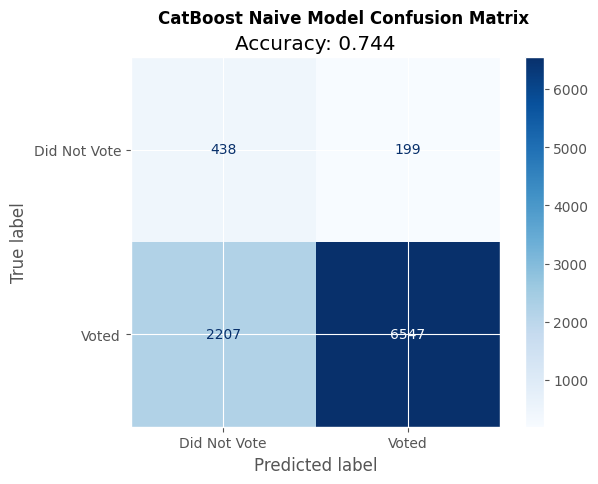

In [97]:
# create a confusion matrix
confusion_matrix_ex(y_test, y_pred, ["Did Not Vote", "Voted"], "CatBoost Naive Model")

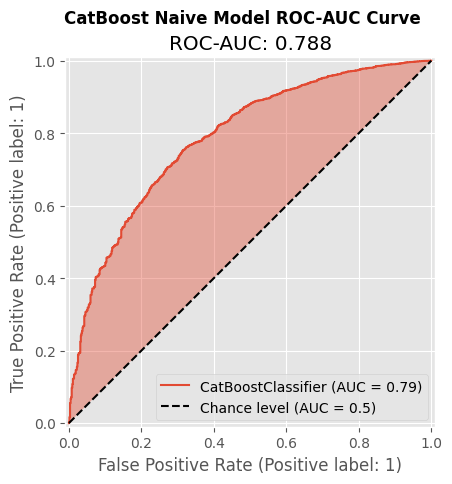

In [98]:
# ROC curve
roc_curve_display_ex(naive_model, X_test, y_test, "CatBoost Naive Model")


## Hyperparameter Tuning

In [99]:
# Defining Optuna function for CatBoost
def cb_objective(trial):
    param = {
        # "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 1, 12),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        'learning_rate': trial.suggest_float('learning_rate', 0.06, 0.09, log=True),
        'iterations': trial.suggest_int('iterations', 100, 1500),
        'eval_metric': 'F1',  # Set F1 as evaluation metric
        'random_strength': trial.suggest_float('random_strength', 0, 1.0),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3, 10.0),
        'random_seed': 42,
        "auto_class_weights": "Balanced",
    }

    naive_model = CatBoostClassifier(**param)
    naive_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=0, early_stopping_rounds=50, cat_features=categorical_features)

    y_f1 = naive_model.predict(X_test)
    score = f1_score(y_test, y_f1, pos_label=0)   # F1 as optimization metric, 0 to maximize minority class F1
    return score

In [100]:
cb_study = optuna.create_study(study_name="catboost_study", direction='maximize', sampler=opt_sampler) 
cb_study.optimize(cb_objective, n_trials=50, show_progress_bar=True, n_jobs=-1)
cb_best_params = cb_study.best_params   

[I 2026-03-14 19:30:58,364] A new study created in memory with name: catboost_study


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-14 19:31:24,478] Trial 25 finished with value: 0.25283921099820683 and parameters: {'colsample_bylevel': 0.04421883666320559, 'depth': 10, 'boosting_type': 'Plain', 'learning_rate': 0.07985693844037207, 'iterations': 122, 'random_strength': 0.8705989012159336, 'l2_leaf_reg': 5.741009130467573}. Best is trial 25 with value: 0.25283921099820683.
[I 2026-03-14 19:32:42,448] Trial 12 finished with value: 0.250561797752809 and parameters: {'colsample_bylevel': 0.055374580228922, 'depth': 9, 'boosting_type': 'Ordered', 'learning_rate': 0.08309044466919056, 'iterations': 186, 'random_strength': 0.9974201365262125, 'l2_leaf_reg': 8.150694188697955}. Best is trial 25 with value: 0.25283921099820683.
[I 2026-03-14 19:36:39,239] Trial 14 finished with value: 0.1279683377308707 and parameters: {'colsample_bylevel': 0.012005501742181998, 'depth': 2, 'boosting_type': 'Plain', 'learning_rate': 0.07851077766490473, 'iterations': 565, 'random_strength': 0.5933701657102235, 'l2_leaf_reg': 9.2

In [101]:
# add "auto_class_weights": "Balanced" to best params to address class imbalance
cb_best_params["auto_class_weights"] = "Balanced"
cb_best_params

{'colsample_bylevel': 0.09895209311772889,
 'depth': 11,
 'boosting_type': 'Plain',
 'learning_rate': 0.088817826415297,
 'iterations': 1020,
 'random_strength': 0.5115970274337067,
 'l2_leaf_reg': 6.031347341068823,
 'auto_class_weights': 'Balanced'}

0:	learn: 0.6850394	test: 0.6855425	best: 0.6855425 (0)	total: 143ms	remaining: 2m 25s
100:	learn: 0.5296433	test: 0.5730376	best: 0.5724015 (99)	total: 14.3s	remaining: 2m 9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5709767665
bestIteration = 132

Shrink model to first 133 iterations.


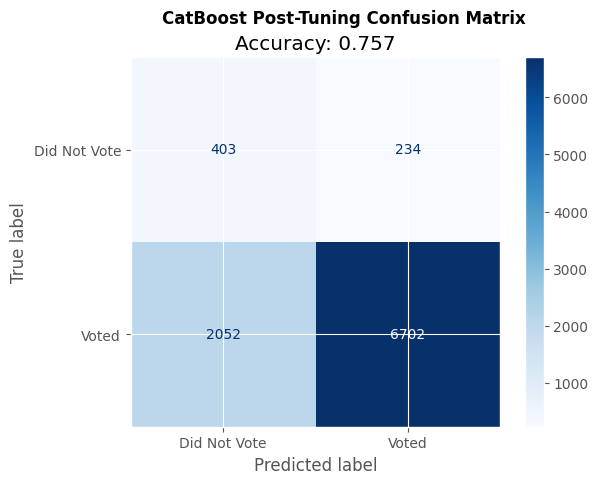

In [102]:
hyper_cb = CatBoostClassifier(**cb_best_params)
hyper_cb.fit(X_train, y_train, cat_features=categorical_features, eval_set=(X_test, y_test), verbose=100, early_stopping_rounds=50)

# Printing Confusion Matrix
y_pred = hyper_cb.predict(X_test)
confusion_matrix_ex(y_test, y_pred, ["Did Not Vote", "Voted"], "CatBoost Post-Tuning")

CatBoost Post-Tuning Accuracy: 0.7565754445745927
CatBoost Post-Tuning ROC-AUC: 0.7751601510536201

Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.63      0.26       637
           1       0.97      0.77      0.85      8754

    accuracy                           0.76      9391
   macro avg       0.57      0.70      0.56      9391
weighted avg       0.91      0.76      0.81      9391



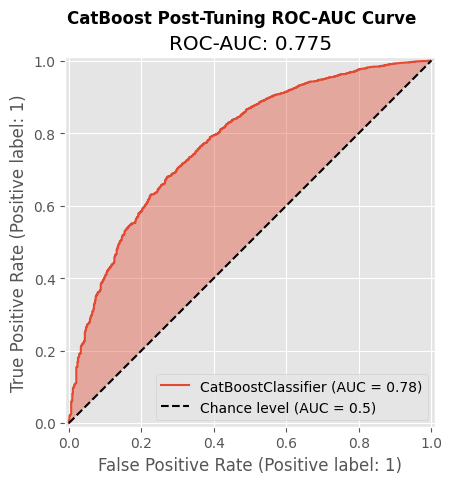

In [103]:
perf_output(hyper_cb, X_test, y_test, "CatBoost Post-Tuning")

## Adding Addtional Features

#### Define more comprehesive list of features

In [104]:

full_features = [
   # Copy from naive
    'VoterAge',         # Age (derived: 2024 - birthyr)
    'gender4',          # Gender
    'educ',             # Education
    'race',             # Race
    'hispanic',         # Hispanic
    'pid3',             # 3 point party ID
    'inputstate',       # State of Residence
    'region',           # Region
    'is_student',       # Student Full or Part-time (derived)

    # Multiracial categories
    "multrace_1",       # Multiracial - White
    "multrace_2",       # Multiracial - Black
    "multrace_3",       # Multiracial - Hispanic
    "multrace_4",       # Multiracial - Asian
    "multrace_5",       # Multiracial - Native American
    "multrace_8",       # Multiracial - Middle Eastern
    "multrace_97",      # Multiracial - Other
    "multrace_98",      # Multiracial - Don't know

    # Device & Registration
    'votereg',          # Voter Registration Status

    # Other
    'pid7',             # 7 point Party ID
    'immstat',          # Immigration background

    # Media consumption (past 24 hrs)
    "CC24_300_1",       # Media use past 24 hrs - Used social media
    "CC24_300_2",       # Media use past 24 hrs - Watched TV news
    "CC24_300_3",       # Media use past 24 hrs - Read a newspaper
    "CC24_300_4",       # Media use past 24 hrs - Listened to radio news
    "CC24_300_5",       # Media use past 24 hrs - None of these

    # Social media use in relation to politics
    "CC24_300d_1",      # Recent social media use - Posted a story, photo, video or link about politics
    "CC24_300d_2",      # Recent social media use - Posted a comment about politics
    "CC24_300d_3",      # Recent social media use - Read a story or watched a video about politics
    "CC24_300d_4",      # Recent social media use - Followed a political event
    "CC24_300d_5",      # Recent social media use - Forwarded a story, photo, video or link about politics to friends
    "CC24_300d_6",      # Recent social media use - None of the above

    # Economic perceptions
    "CC24_301",         # National Economics
    "CC24_302",         # Household income change
    "CC24_303",         # Price change in past year

    # Life changes
    "CC24_305_1",       # Life Changes - Married
    "CC24_305_2",       # Life Changes - Lost a job
    "CC24_305_3",       # Life Changes - Finished school
    "CC24_305_4",       # Life Changes - Retired
    "CC24_305_5",       # Life Changes - Divorced
    "CC24_305_6",       # Life Changes - Had a child
    "CC24_305_7",       # Life Changes - Taken a new job
    "CC24_305_9",       # Life Changes - Been a victim of a crime
    "CC24_305_10",      # Life Changes - Visited an emergency room
    "CC24_305_11",      # Life Changes - Visited a doctor for a regular examination
    "CC24_305_12",      # Life Changes - Received a raise at work
    "CC24_305_13",      # Life Changes - Had a pay cut at work
    "CC24_305_14",      # Life Changes - None of the above

    # Health status
    "CC24_309e",        # General health

    # Emergency expenses
    "CC24_309d_1",      # Emergency expense - Put it on credit card, pay off in full
    "CC24_309d_2",      # Emergency expense - Put it on credit card, pay off over time
    "CC24_309d_3",      # Emergency expense - With checking/savings or cash
    "CC24_309d_4",      # Emergency expense - Bank loan or line of credit
    "CC24_309d_5",      # Emergency expense - Borrowing from friend or family
    "CC24_309d_6",      # Emergency expense - Payday loan, deposit advance, or overdraft
    "CC24_309d_7",      # Emergency expense - By selling something
    "CC24_309d_8",      # Emergency expense - Wouldn't be able to pay right now

    # Knowledge of current politicians
    "CC24_310a",        # Know Party in Government - U.S. House of Representatives
    "CC24_310b",        # Know Party in Government - U.S. Senate

    # Miscellaneous
    "urbancity",        # Type of Area Living In
    "ideo5",            # Ideology
    "IsParent",         # Parent of any child either younger or older than 18 (derived)
    "child18",          # Parent of child under 18
    "employ",           # Employment Status
    "investor",         # Stock ownership
    "newsint",          # Political Interest
    "faminc_new",       # Family income
    "marstat",          # Marital Status
    "union",            # Labor union member
    "ownhome",          # Home ownership
    "industry",         # Industry of employment
    "jobnum",           # Number of jobs
    "sexuality",        # Sexual Orientation
    "transgender",      # Transgender

    # Religious habit
    "pew_religimp",     # Importance of religion (Pew version)
    "is_religious",     # Organized religion (derived)

    # Election habits
    "CC24_421_1",       # Election fair - Elections in the U.S. are fair
    "CC24_421_2",       # Election fair - State/local government conducted fair and accurate election in 2024
    "CC24_423",         # Trust in federal government
    "CC24_424",         # Trust in state government

    # Past year political engagement
    "CC24_430a_1",      # Past year - Attend local political meetings
    "CC24_430a_2",      # Past year - Put up a political sign
    "CC24_430a_3",      # Past year - Work for a candidate or campaign
    "CC24_430a_4",      # Past year - Attend a political protest, march or demonstration
    "CC24_430a_5",      # Past year - Contact a public official
    "CC24_430a_6",      # Past year - Donate money to a candidate, campaign, or political organization
    "CC24_430a_7",      # Past year - Donate blood
    "CC24_430a_8",      # Past year - None of these

    # Money donation
    "CC24_430b_1",      # Donate money - Candidate for President
    "CC24_430b_2",      # Donate money - Candidate for U.S. Senate in my state
    "CC24_430b_3",      # Donate money - Candidate for U.S. Senate in another state
    "CC24_430b_4",      # Donate money - Candidate for U.S. House in my state
    "CC24_430b_5",      # Donate money - Candidate for U.S. House in another state
    "CC24_430b_6",      # Donate money - Candidate for state office
    "CC24_430b_7",      # Donate money - Political party committee
    "CC24_430b_8",      # Donate money - Political action committee at work
    "CC24_430b_9",      # Donate money - Political group
    "CC24_430b_10",     # Donate money - Other
    "CC24_430c",        # Donate money - total amount

    # Campaign contact
    "CC24_431a",        # Contacted by candidate or political campaign

    # Other post-election
    "gunown",           # Personal gun ownership
    "numchildren",      # Number of children
    "gigwork",          # Gig work
    "edloan",           # Student debtor

    # Voting history
    # "presvote20post",   # 2020 President Vote Post Election
    # "presvote16post",   # 2016 President Vote Post Election
    "voted_2016",       # Voted in 2016 election (derived)
    "voted_2020",       # Voted in 2020 election (derived)

    # other derived features
    "any_media_use",      # Used any media in past 24 hrs (derived)
    "any_pol_social_media", # Used social media for politics (derived)
    "any_political_engagement", # Engaged in any political activity in past year (derived)
    "any_donation",          # Donated money to politics (derived)
    "always_vote",          # Always votes (derived from past vote history
    "higher_educ",           # More than high school education (derived)
    
]

In [105]:
len(full_features)

111

#### Model with Full Feature Set

In [106]:
# categorical features = everything except continuous ones
NUMERIC_FEATURES = ['VoterAge', 'CC24_430c', 'numchildren', 'jobnum', 'numchildren']
cat_features = [f for f in full_features if f not in NUMERIC_FEATURES]

In [107]:
# define X and y
X = Voting_df[full_features].copy()
y = Voting_df['VoteFlag'].astype(int) # target variable, convert to binary

In [108]:
# fill in missing values
for col in X.columns:
    X[col] = X[col].fillna(-1).astype(int)

In [109]:
# train/val/test split (70/15/15) with stratification on target variable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)

In [110]:
# check splits
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"VoteFlag rate — Train: {y_train.mean():.1%} | Val: {y_val.mean():.1%} | Test: {y_test.mean():.1%}")

Train: 32,865 | Val: 7,043 | Test: 7,043
VoteFlag rate — Train: 93.2% | Val: 93.2% | Test: 93.2%


In [111]:
# build model
cb_model = CatBoostClassifier(
    cat_features=cat_features,
    **cb_best_params
)

In [112]:
# fit model
cb_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	learn: 0.6471569	test: 0.6515558	best: 0.6515558 (0)	total: 427ms	remaining: 7m 14s
1:	learn: 0.6068437	test: 0.6165655	best: 0.6165655 (1)	total: 812ms	remaining: 6m 53s
2:	learn: 0.5773856	test: 0.5882540	best: 0.5882540 (2)	total: 1.22s	remaining: 6m 53s
3:	learn: 0.5465095	test: 0.5647064	best: 0.5647064 (3)	total: 1.63s	remaining: 6m 52s
4:	learn: 0.5269603	test: 0.5463826	best: 0.5463826 (4)	total: 1.84s	remaining: 6m 14s
5:	learn: 0.5054981	test: 0.5295744	best: 0.5295744 (5)	total: 2.27s	remaining: 6m 22s
6:	learn: 0.4848684	test: 0.5152985	best: 0.5152985 (6)	total: 2.68s	remaining: 6m 27s
7:	learn: 0.4673201	test: 0.5023566	best: 0.5023566 (7)	total: 3.11s	remaining: 6m 33s
8:	learn: 0.4524636	test: 0.4934049	best: 0.4934049 (8)	total: 3.59s	remaining: 6m 43s
9:	learn: 0.4336937	test: 0.4864223	best: 0.4864223 (9)	total: 4.06s	remaining: 6m 49s
10:	learn: 0.4194626	test: 0.4797506	best: 0.4797506 (10)	total: 4.58s	remaining: 6m 59s
11:	learn: 0.4068187	test: 0.4766611	best

CatBoostClassifier(auto_class_weights='Balanced', boosting_type='Plain', cat_features=['gender4', 'educ', 'race', 'hispanic', 'pid3', 'inputstate', 'region', 'is_student', 'multrace_1', 'multrace_2', 'multrace_3', 'multrace_4', 'multrace_5', 'multrace_8', 'multrace_97', 'multrace_98', 'votereg', 'pid7', 'immstat', 'CC24_300_1', 'CC24_300_2', 'CC24_300_3', 'CC24_300_4', 'CC24_300_5', 'CC24_300d_1', 'CC24_300d_2', 'CC24_300d_3', 'CC24_300d_4', 'CC24_300d_5', 'CC24_300d_6', 'CC24_301', 'CC24_302', 'CC24_303', 'CC24_305_1', 'CC24_305_2', 'CC24_305_3', 'CC24_305_4', 'CC24_305_5', 'CC24_305_6', 'CC24_305_7', 'CC24_305_9', 'CC24_305_10', 'CC24_305_11', 'CC24_305_12', 'CC24_305_13', 'CC24_305_14', 'CC24_309e', 'CC24_309d_1', 'CC24_309d_2', 'CC24_309d_3', 'CC24_309d_4', 'CC24_309d_5', 'CC24_309d_6', 'CC24_309d_7', 'CC24_309d_8', 'CC24_310a', 'CC24_310b', 'urbancity', 'ideo5', 'IsParent', 'child18', 'employ', 'investor', 'newsint', 'faminc_new', 'marstat', 'union', 'ownhome', 'industry', 'sexual

In [113]:
# evaluate on validation set
val_probs = cb_model.predict_proba(X_val)[:, 1]
val_preds = cb_model.predict(X_val)
print(f"\nValidation AUC: {roc_auc_score(y_val, val_probs):.4f}")
print(classification_report(y_val, val_preds))


Validation AUC: 0.8764
              precision    recall  f1-score   support

           0       0.28      0.73      0.41       478
           1       0.98      0.87      0.92      6565

    accuracy                           0.86      7043
   macro avg       0.63      0.80      0.66      7043
weighted avg       0.93      0.86      0.88      7043



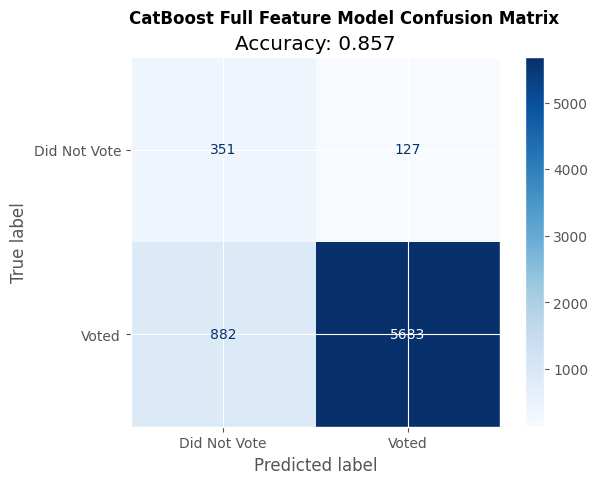

In [114]:
# confusion matrix
confusion_matrix_ex(y_val, val_preds, ["Did Not Vote", "Voted"], "CatBoost Full Feature Model")

CatBoost Full Feature Model Accuracy: 0.856737185858299
CatBoost Full Feature Model ROC-AUC: 0.8764463507824873

Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.73      0.41       478
           1       0.98      0.87      0.92      6565

    accuracy                           0.86      7043
   macro avg       0.63      0.80      0.66      7043
weighted avg       0.93      0.86      0.88      7043



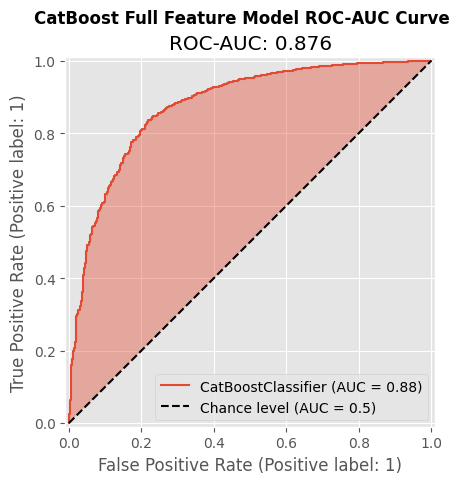

In [115]:
# roc curve
perf_output(cb_model, X_val, y_val, "CatBoost Full Feature Model")

In [116]:
# feature importance 
feat_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=full_features
).sort_values(ascending=False)

print("\nTop 20 features:")
print(feat_imp.head(20))

print("\nBottom 10 features (candidates to drop):")
print(feat_imp.tail(10))


Top 20 features:
CC24_421_2      5.347121
investor        4.845695
CC24_431a       4.753311
always_vote     4.416688
marstat         4.315788
pid7            3.980680
VoterAge        3.772913
CC24_300d_3     3.108409
ownhome         2.964778
CC24_301        2.897145
ideo5           2.842992
newsint         2.687488
voted_2020      2.576905
CC24_430a_8     2.536818
CC24_310a       2.262787
is_religious    2.223286
gigwork         2.108827
jobnum          1.984214
CC24_300d_6     1.967822
CC24_309d_1     1.857734
dtype: float64

Bottom 10 features (candidates to drop):
CC24_430a_2      0.0
CC24_430a_7      0.0
CC24_430b_5      0.0
CC24_430b_6      0.0
CC24_430b_2      0.0
CC24_430b_1      0.0
CC24_430a_4      0.0
CC24_430a_3      0.0
gunown           0.0
any_media_use    0.0
dtype: float64


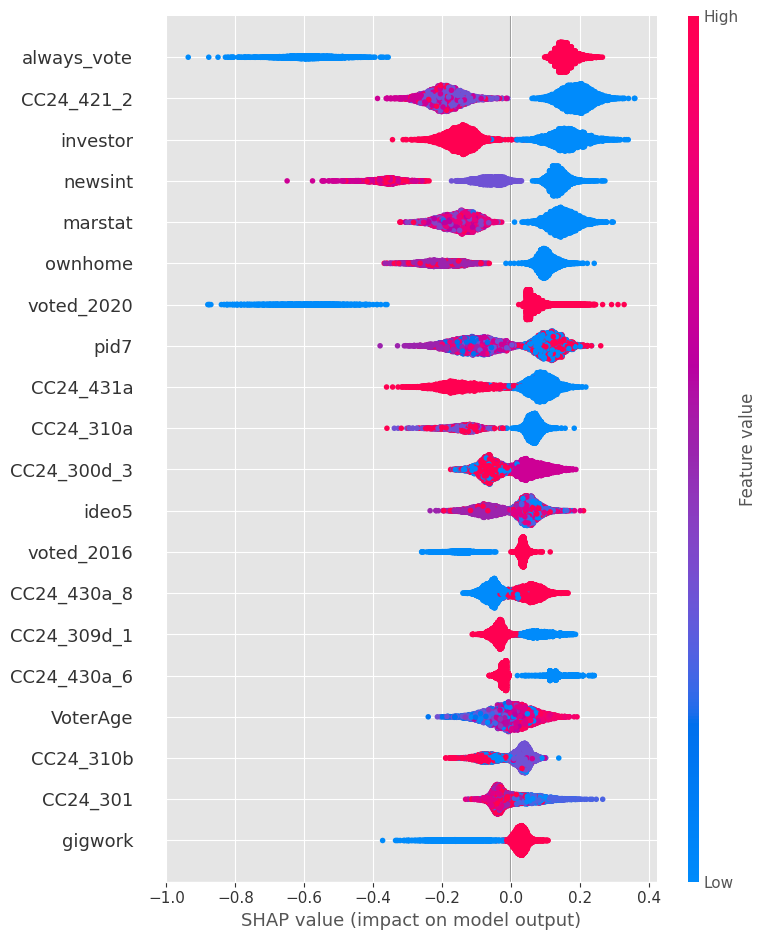

In [117]:
# compute shap values
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_val)

shap_explaination = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_val,
    feature_names=full_features
)

# SHAP summary plot
shap.summary_plot(shap_values, X_val, feature_names=full_features, max_display=20)

## Feature pruning

In [118]:
# get feature importance from model
feat_imp = pd.Series(
    cb_model.get_feature_importance(),
    index=full_features
).sort_values(ascending=False)

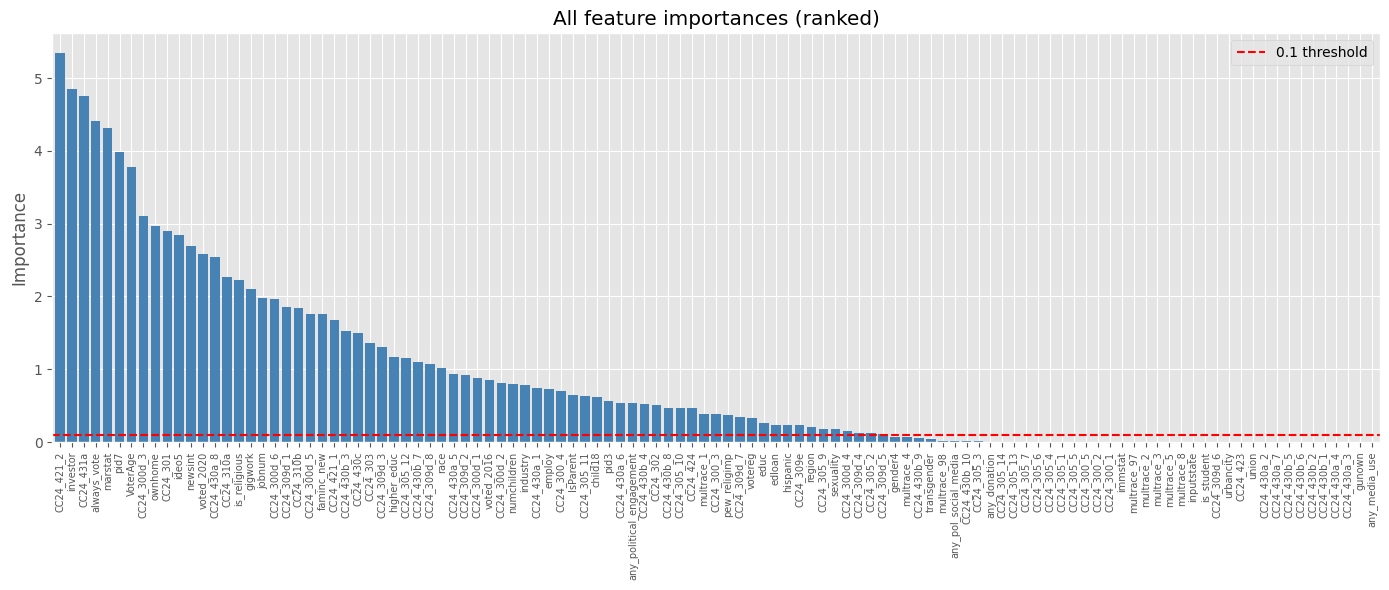

In [119]:
# visualize distribution
fig, axes = plt.subplots(figsize=(14, 6))

# Left: full ranked importance
feat_imp.plot(kind='bar', ax=axes, color='steelblue', width=0.8)
axes.set_title("All feature importances (ranked)")
axes.set_xlabel("")
axes.set_ylabel("Importance")
axes.tick_params(axis='x', labelsize=7)
axes.axhline(y=0.1, color='red', linestyle='--', label='0.1 threshold')
axes.legend()

plt.tight_layout()
plt.show()

In [120]:
# print pruning summary
print("=" * 55)
print(f"Total features: {len(feat_imp)}")
print("=" * 55)

for threshold in [0.05, 0.10, 0.20, 0.50]:
    to_drop = feat_imp[feat_imp < threshold]
    to_keep = feat_imp[feat_imp >= threshold]
    pct_importance_kept = feat_imp[feat_imp >= threshold].sum() / feat_imp.sum() * 100
    print(f"\nThreshold {threshold}:")
    print(f"  Keep: {len(to_keep):3d} features  |  "
          f"Drop: {len(to_drop):3d} features  |  "
          f"Importance retained: {pct_importance_kept:.1f}%")

Total features: 111

Threshold 0.05:
  Keep:  73 features  |  Drop:  38 features  |  Importance retained: 99.9%

Threshold 0.1:
  Keep:  70 features  |  Drop:  41 features  |  Importance retained: 99.7%

Threshold 0.2:
  Keep:  64 features  |  Drop:  47 features  |  Importance retained: 98.8%

Threshold 0.5:
  Keep:  51 features  |  Drop:  60 features  |  Importance retained: 94.4%


In [121]:
# with 0.1 threshold
THRESHOLD = 0.10   # <-- adjust after reviewing the plot

features_to_drop = feat_imp[feat_imp < THRESHOLD].index.tolist()
features_to_keep = feat_imp[feat_imp >= THRESHOLD].index.tolist()

print(f"\n── Features to DROP (importance < {THRESHOLD}) ──────────────────")
drop_df = feat_imp[features_to_drop].reset_index()
drop_df.columns = ['feature', 'importance']
print(drop_df.to_string(index=False))

print(f"\n── Top 20 features to KEEP ──────────────────────────────────────")
print(feat_imp.head(20).to_string())


── Features to DROP (importance < 0.1) ──────────────────
             feature  importance
             gender4    0.074788
          multrace_4    0.068156
         CC24_430b_9    0.054976
         transgender    0.043302
         multrace_98    0.020015
any_pol_social_media    0.019114
        CC24_430b_10    0.013600
          CC24_305_3    0.007695
        any_donation    0.003602
         CC24_305_14    0.000000
         CC24_305_13    0.000000
          CC24_305_7    0.000000
          CC24_305_6    0.000000
          CC24_305_4    0.000000
          CC24_305_1    0.000000
          CC24_305_5    0.000000
          CC24_300_5    0.000000
          CC24_300_2    0.000000
          CC24_300_1    0.000000
             immstat    0.000000
         multrace_97    0.000000
          multrace_2    0.000000
          multrace_3    0.000000
          multrace_5    0.000000
          multrace_8    0.000000
          inputstate    0.000000
          is_student    0.000000
         CC24_309

In [122]:
# retrain model with pruned features
NUMERIC_FEATURES = {'VoterAge', 'CC24_430c', 'numchildren', 'jobnum'}
cat_features_pruned = [f for f in features_to_keep if f not in NUMERIC_FEATURES]

pruned_model = CatBoostClassifier(
    cat_features=cat_features_pruned,
    **cb_best_params

)
pruned_model.fit(X_train[features_to_keep], y_train, eval_set=(X_val[features_to_keep], y_val), early_stopping_rounds=50)


0:	learn: 0.6425371	test: 0.6507684	best: 0.6507684 (0)	total: 694ms	remaining: 11m 47s
1:	learn: 0.6071887	test: 0.6161560	best: 0.6161560 (1)	total: 1.39s	remaining: 11m 46s
2:	learn: 0.5676673	test: 0.5873794	best: 0.5873794 (2)	total: 2.04s	remaining: 11m 33s
3:	learn: 0.5443366	test: 0.5660754	best: 0.5660754 (3)	total: 2.73s	remaining: 11m 33s
4:	learn: 0.5180262	test: 0.5483765	best: 0.5483765 (4)	total: 3.41s	remaining: 11m 32s
5:	learn: 0.4971184	test: 0.5326777	best: 0.5326777 (5)	total: 4.09s	remaining: 11m 31s
6:	learn: 0.4773304	test: 0.5192522	best: 0.5192522 (6)	total: 4.77s	remaining: 11m 30s
7:	learn: 0.4601751	test: 0.5072475	best: 0.5072475 (7)	total: 5.46s	remaining: 11m 31s
8:	learn: 0.4395883	test: 0.4959843	best: 0.4959843 (8)	total: 6.15s	remaining: 11m 31s
9:	learn: 0.4261536	test: 0.4865444	best: 0.4865444 (9)	total: 6.86s	remaining: 11m 32s
10:	learn: 0.4115322	test: 0.4818964	best: 0.4818964 (10)	total: 7.59s	remaining: 11m 36s
11:	learn: 0.4080379	test: 0.4

CatBoostClassifier(auto_class_weights='Balanced', boosting_type='Plain', cat_features=['CC24_421_2', 'investor', 'CC24_431a', 'always_vote', 'marstat', 'pid7', 'CC24_300d_3', 'ownhome', 'CC24_301', 'ideo5', 'newsint', 'voted_2020', 'CC24_430a_8', 'CC24_310a', 'is_religious', 'gigwork', 'CC24_300d_6', 'CC24_309d_1', 'CC24_310b', 'CC24_300d_5', 'faminc_new', 'CC24_421_1', 'CC24_430b_3', 'CC24_303', 'CC24_309d_3', 'higher_educ', 'CC24_305_12', 'CC24_430b_7', 'CC24_309d_8', 'race', 'CC24_430a_5', 'CC24_309d_2', 'CC24_300d_1', 'voted_2016', 'CC24_300d_2', 'industry', 'CC24_430a_1', 'employ', 'CC24_300_4', 'IsParent', 'CC24_305_11', 'child18', 'pid3', 'CC24_430a_6', 'any_political_engagement', 'CC24_430b_4', 'CC24_302', 'CC24_430b_8', 'CC24_305_10', 'CC24_424', 'multrace_1', 'CC24_300_3', 'pew_religimp', 'CC24_309d_7', 'votereg', 'educ', 'edloan', 'hispanic', 'CC24_309e', 'region', 'CC24_305_9', 'sexuality', 'CC24_300d_4', 'CC24_309d_4', 'CC24_305_2', 'CC24_309d_5'], colsample_bylevel=0.0989

In [123]:
pruned_auc = roc_auc_score(y_val, pruned_model.predict_proba(X_val[features_to_keep])[:, 1])
original_auc = roc_auc_score(y_val, cb_model.predict_proba(X_val)[:, 1])

print(f"\n── AUC comparison ───────────────────────────────────────────────")
print(f"  Original  ({len(full_features):3d} features): {original_auc:.4f}")
print(f"  Pruned    ({len(features_to_keep):3d} features): {pruned_auc:.4f}")
print(f"  Difference:               {pruned_auc - original_auc:+.4f}")


── AUC comparison ───────────────────────────────────────────────
  Original  (111 features): 0.8764
  Pruned    ( 70 features): 0.8756
  Difference:               -0.0009


In [124]:
# evaluate on test set
test_probs = pruned_model.predict_proba(X_test[features_to_keep])[:, 1]
test_preds = pruned_model.predict(X_test[features_to_keep])
print(f"\nTest AUC: {roc_auc_score(y_test, test_probs):.4f}")
print(classification_report(y_test, test_preds))


Test AUC: 0.8646
              precision    recall  f1-score   support

           0       0.26      0.68      0.38       478
           1       0.97      0.86      0.91      6565

    accuracy                           0.85      7043
   macro avg       0.62      0.77      0.65      7043
weighted avg       0.93      0.85      0.88      7043



## Final Evaluation

In [125]:
# evaluate cb_model on test set
test_probs = cb_model.predict_proba(X_test)[:, 1]
test_preds = cb_model.predict(X_test)
print(f"\nTest AUC: {roc_auc_score(y_test, test_probs):.4f}")
print(classification_report(y_test, test_preds))


Test AUC: 0.8671
              precision    recall  f1-score   support

           0       0.27      0.70      0.39       478
           1       0.98      0.86      0.91      6565

    accuracy                           0.85      7043
   macro avg       0.62      0.78      0.65      7043
weighted avg       0.93      0.85      0.88      7043



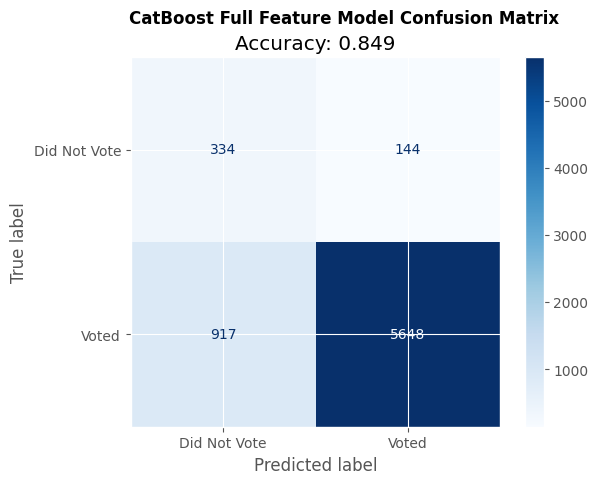

In [126]:
# confusion matrix
confusion_matrix_ex(y_test, test_preds, ["Did Not Vote", "Voted"], "CatBoost Full Feature Model")

CatBoost Full Feature Model Accuracy: 0.8493539684793412
CatBoost Full Feature Model ROC-AUC: 0.8671020722928424

Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.70      0.39       478
           1       0.98      0.86      0.91      6565

    accuracy                           0.85      7043
   macro avg       0.62      0.78      0.65      7043
weighted avg       0.93      0.85      0.88      7043



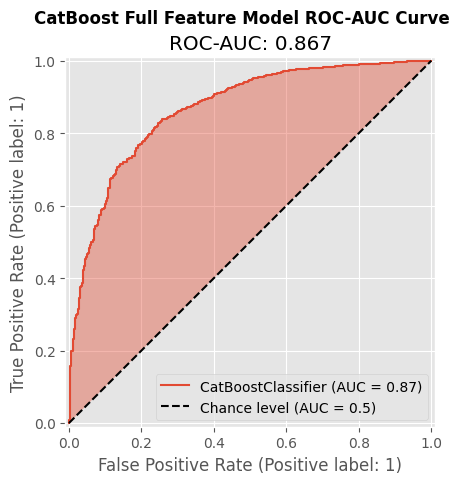

In [127]:
# roc curve
perf_output(cb_model, X_test, y_test, "CatBoost Full Feature Model")

In [128]:
# Collecting model statistics
collect_stats(cb_model, "CatBoost")

# Final Model Selection
Though it appears as the first model in our analysis, we ultimately chose the F1-Optimized XGBoost as our most meaningful predictive model.
Even with its relatively simple implementation, the following justify its selection:
* It competed for the highest ROC-AUC of all models (~0.869) against CatBoost, more meaningful than accuracy given our concern for the negative minority class (nonvoters). CatBoost sometimes performed at the cost of significant computational expense.
* Our optimization towards minority class F1 proved fruitful with post-undersampling XGBoost, achieving 0.364 even on the test set.
* XGBoost was able to natively handle the sheer amount of NA data in our source, a problem common to survey data.

Given the severe class imbalance we observed, XGBoost's robustness towards missing information, its cheaper computational cost, and most importantly the practical cost of missing nonvoters: we present XGBoost's feature importance as that most relevant to later decision making.

In [129]:
display(results_df)

,model,accuracy,roc-auc,weightedF1,minorityF1
0,XGBoost,0.810024,0.869732,0.850098,0.364672
1,Naive Bayes,0.794122,0.857142,0.838981,0.345077
2,CatBoost,0.849354,0.867102,0.878317,0.386350
